# Homework 2

Daniel Ott (33551440), Samuel Šmíd (73123255), Anna Turnerová (70701808)

For the econometric analysis, we use the datasets from the folder 70701808

## Packages

In [3]:
required_packages <- c("rugarch", "forecast", "FinTS", "ggplot2", "patchwork", "tseries")
  new_packages <- required_packages[!(required_packages %in% installed.packages()[, "Package"])]                                                    
  if (length(new_packages) > 0) install.packages(new_packages)                                                                                      
                                                                                                                                                    
  library(rugarch)   
  library(forecast)                                                                                 
  library(FinTS)                                                                                                           
  library(ggplot2)                                                                                                                      
  library(patchwork) 
  library(tseries)

Warning message:
"package 'rugarch' was built under R version 4.5.2"
Loading required package: parallel

Warning message:
"package 'forecast' was built under R version 4.5.2"
Warning message:
"package 'FinTS' was built under R version 4.5.3"
Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric



Attaching package: 'FinTS'


The following object is masked from 'package:forecast':

    Acf


Warning message:
"package 'patchwork' was built under R version 4.5.3"
Warning message:
"package 'tseries' was built under R version 4.5.2"
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



#### Problem 0: Loading the data

The folder 70701808 should be placed next to this ipynb file for the data loading to work properly

In [4]:
data_dir <- file.path(getwd(), "70701808")                                                                                                        
  if (!dir.exists(data_dir)) {                                                                                                                      
    stop("Data folder '70701808' not found. Place it in the same directory as this notebook.")                                                      
  }                                                                                                                                                                                                                                           

In [5]:
  # We load the three csv files as data frames
  series_A <- read.csv(file.path(data_dir, "series_A.csv"))                                                                                         
  series_B <- read.csv(file.path(data_dir, "series_B.csv"))                                                                                         
  series_C <- read.csv(file.path(data_dir, "series_C.csv"))                                                                                         
                                                                                                                                                    
  # We extract return series as ts objects (we use it later for the ACF, PACF, ARMA, GARCH)
  ret_A <- ts(series_A$ret)                                                                                                                         
  ret_B <- ts(series_B$ret)
  ret_C <- ts(series_C$ret)

We check if there are any inconsistencies in the data

In [6]:
head(series_A)
head(series_B)
head(series_C)

,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,0.003333625,1e-04
2,2,-0.014436324,1e-04
3,3,-0.014714092,1e-04
4,4,-0.002892057,1e-04
5,5,-0.001163418,1e-04
6,6,-0.017577014,1e-04


,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,0.001565492,0.0004319325
2,2,-0.013465665,0.0003565024
3,3,0.002000053,0.0003315146
4,4,-0.019286075,0.0002785568
5,5,-0.013757246,0.0003160698
6,6,0.007472438,0.0003432863


,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,0.0060400710,8.515252e-05
2,2,-0.0097483423,8.130506e-05
3,3,-0.0004913637,8.327098e-05
4,4,-0.0138233888,7.540007e-05
5,5,0.0132157861,1.042986e-04
6,6,0.0017989999,1.008171e-04


In [7]:
head(series_A$sigma2_true)

[1] 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04

Upon initial inspection, it seems that series A has a constant variance of 0,0001. We verify if there is any variation in the variance

In [8]:
all(series_A$sigma2_true == series_A$sigma2_true[1])                                                                                              
  unique(series_A$sigma2_true) 

[1] TRUE

[1] 1e-04

This verifies that the variance of series_A is constant in all rows. We keep this information in mind for later analysis. Meanwhile we check if there are any missing values (gaps in the series)

In [9]:
for (name in c("series_A", "series_B", "series_C")) {
    df <- get(name)                                                                                                                                 
    cat("---", name, "---\n")                                                                                                                       
    cat("Rows:", nrow(df), "\n")                                                                                                                    
    cat("NAs per column:\n")                                                                                                                        
    print(colSums(is.na(df)))                                                                                                                       
    cat("Expected t sequence (1 to", nrow(df), "):", all(df$t == seq_len(nrow(df))), "\n\n")                                                        
  } 

--- series_A ---
Rows: 4000 
NAs per column:
          t         ret sigma2_true 
          0           0           0 
Expected t sequence (1 to 4000 ): TRUE 

--- series_B ---
Rows: 4000 
NAs per column:
          t         ret sigma2_true 
          0           0           0 
Expected t sequence (1 to 4000 ): TRUE 

--- series_C ---
Rows: 4000 
NAs per column:
          t         ret sigma2_true 
          0           0           0 
Expected t sequence (1 to 4000 ): TRUE 



All three series have the same number of rows and there seem to be no missing values in any column. Lastly, we look for type consistency in the columns.

In [10]:
str(series_A)                                                                                                                                     
str(series_B)
str(series_C) 

'data.frame':	4000 obs. of  3 variables:
 $ t          : int  1 2 3 4 5 6 7 8 9 10 ...
 $ ret        : num  0.00333 -0.01444 -0.01471 -0.00289 -0.00116 ...
 $ sigma2_true: num  1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 ...
'data.frame':	4000 obs. of  3 variables:
 $ t          : int  1 2 3 4 5 6 7 8 9 10 ...
 $ ret        : num  0.00157 -0.01347 0.002 -0.01929 -0.01376 ...
 $ sigma2_true: num  0.000432 0.000357 0.000332 0.000279 0.000316 ...
'data.frame':	4000 obs. of  3 variables:
 $ t          : int  1 2 3 4 5 6 7 8 9 10 ...
 $ ret        : num  0.00604 -0.009748 -0.000491 -0.013823 0.013216 ...
 $ sigma2_true: num  8.52e-05 8.13e-05 8.33e-05 7.54e-05 1.04e-04 ...


Seems fine as well, we proceed to the analytic part of this assignment

### Problem 1: Preliminary analysis

In [11]:
# --- Helper: build a single return plot ---                                                                                                      
  make_ret_plot <- function(ret_vec, label) {                                                                                                       
    df <- data.frame(t = seq_along(ret_vec), ret = as.numeric(ret_vec))                                                                             
    ggplot(df, aes(x = t, y = ret)) +                                                                                                               
      geom_line(color = "steelblue", linewidth = 0.3) +                                                                                             
      labs(title = paste("Returns –", label), x = "t", y = "Return") +                                                                              
      theme_minimal()                                                                                                                               
  }                                                                                                                                                 
                                                                                                                                                    
  # --- Helper: build a single squared-return plot ---                                                                                              
  make_sq_plot <- function(ret_vec, label) {
    df <- data.frame(t = seq_along(ret_vec), sq = as.numeric(ret_vec)^2)                                                                            
    ggplot(df, aes(x = t, y = sq)) +                                                                                                                
      geom_line(color = "firebrick", linewidth = 0.3) +                                                                                             
      labs(title = paste("Squared Returns –", label), x = "t", y = expression(Return^2)) +                                                          
      theme_minimal()                                                                                                                               
  }                                                                                                                                                 
                                                                                                                                                    
  # --- Build all 6 panels ---                                                                                                                      
  p_retA <- make_ret_plot(ret_A, "Series A")
  p_retB <- make_ret_plot(ret_B, "Series B")                                                                                                        
  p_retC <- make_ret_plot(ret_C, "Series C")                                                                                                        
                                                                                                                                                    
  p_sqA  <- make_sq_plot(ret_A, "Series A")                                                                                                         
  p_sqB  <- make_sq_plot(ret_B, "Series B")                                                                                                         
  p_sqC  <- make_sq_plot(ret_C, "Series C")      

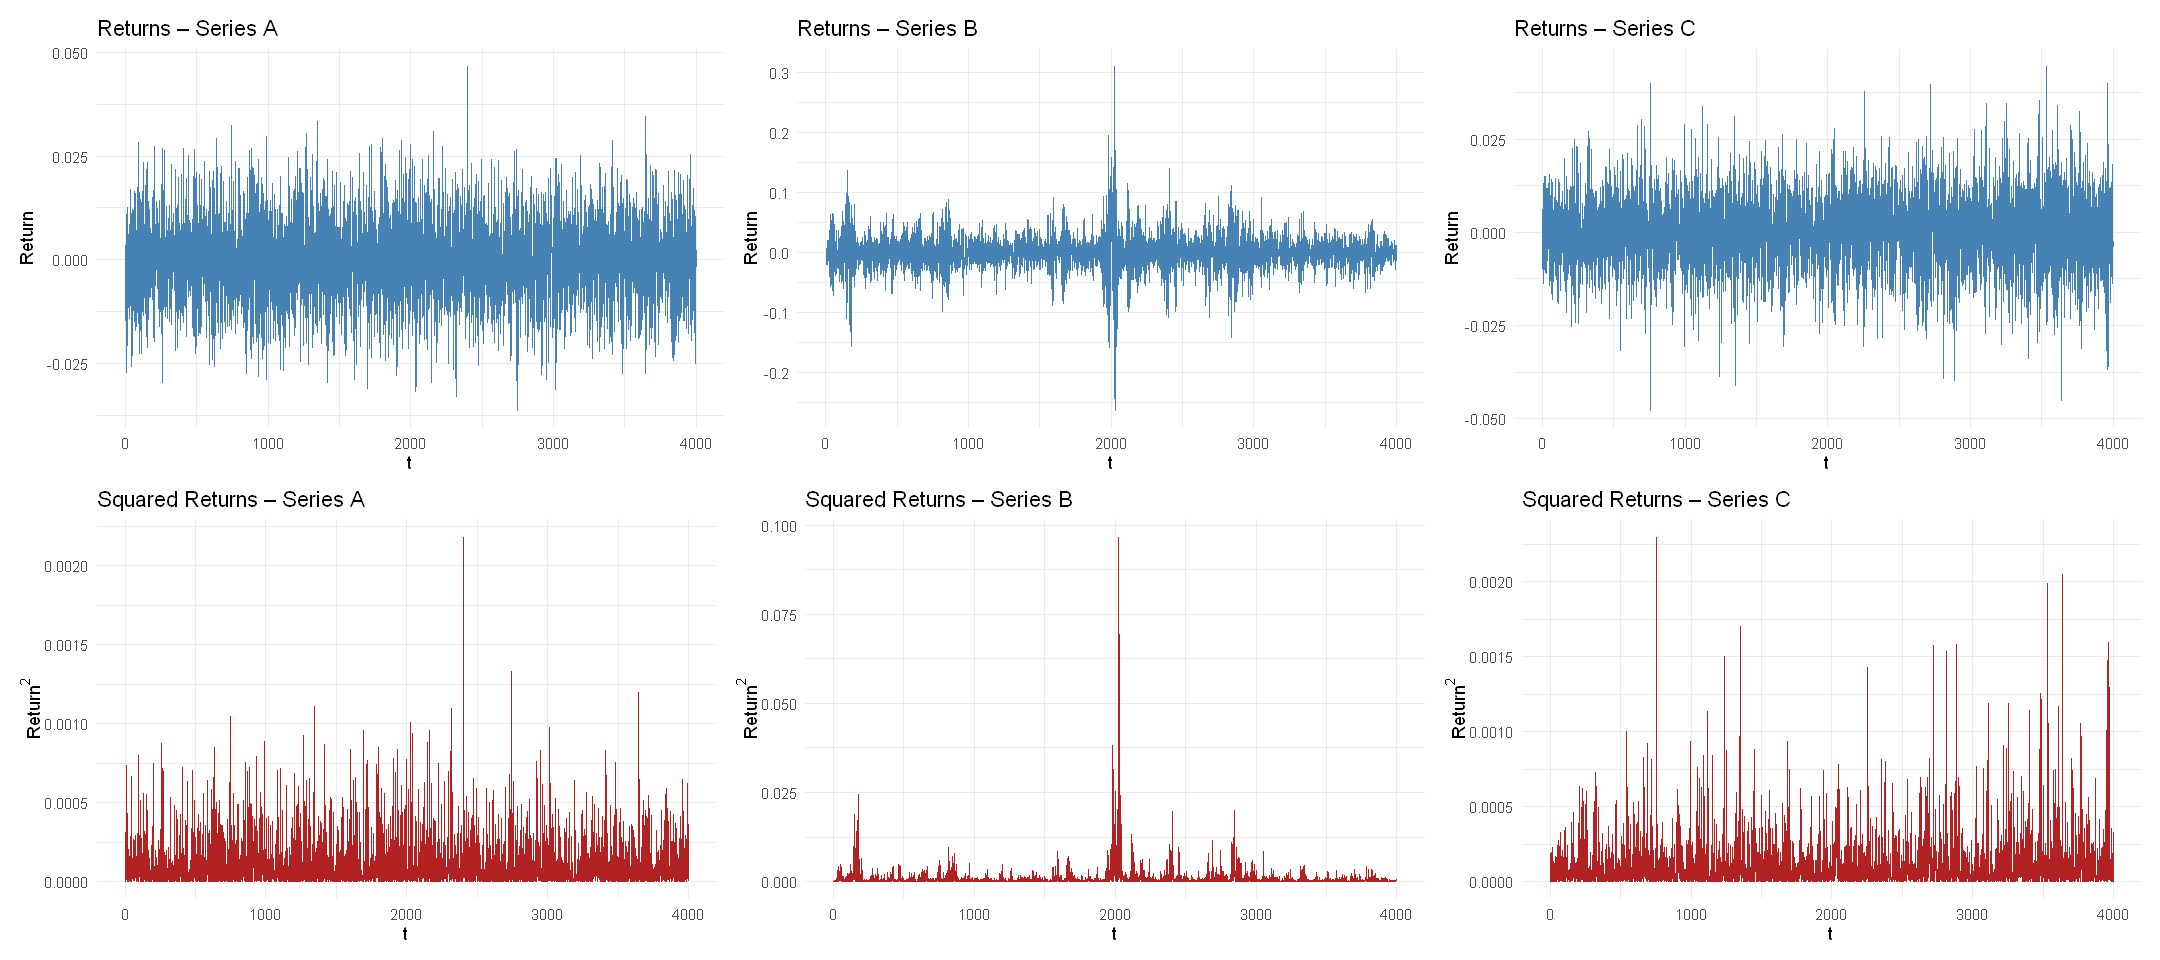

In [12]:
 # --- Combine: returns on top row, squared returns on bottom row ---                                                                              
options(repr.plot.width = 18, repr.plot.height = 8)                                                                                               
  (p_retA | p_retB | p_retC) / (p_sqA | p_sqB | p_sqC)

Based on visual inspection, we form the following hypotheses about volatility clustering of the series:
* least persistent volatilty clustering: Series A - The returns seem to fluctuate uniformly throughout the entire sample and the squared returns show no apparent pattern. The spikes seem to be randomly scattered. This is in line with the fact that the variance of Series A is constant across all time periods. 
* intermediate volatility clustering: Series C
* most persistent volatility clustering: Series B - We suspect the highest volatility clustering for Series B.

### Disclaimer

#### Contributions:

Daniel Ott - Problem 5, Problem 2

Anna Turnerová - Data Preparation, Problem 3, Problem 1

Samuel Šmíd - Problem 4, Problem 6

#### AI usage:

The members of this team used ChatGPT and Google Gemini to help refine the code, especially for the data cleaning and data visualization parts, as well as for polishing of written text.

### Problem 2:  Identification of the conditional mean

From previous analysis all time series of returns seem to be stationary, lets compare the visual inspection with formal test.

In [13]:
print(adf.test(series_A$ret, k = 1))
print(adf.test(series_B$ret, k = 1))
print(adf.test(series_C$ret, k = 1))

Warning message in adf.test(series_A$ret, k = 1):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  series_A$ret
Dickey-Fuller = -55.943, Lag order = 1, p-value = 0.01
alternative hypothesis: stationary



Warning message in adf.test(series_B$ret, k = 1):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  series_B$ret
Dickey-Fuller = -50.839, Lag order = 1, p-value = 0.01
alternative hypothesis: stationary



Warning message in adf.test(series_C$ret, k = 1):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  series_C$ret
Dickey-Fuller = -54.29, Lag order = 1, p-value = 0.01
alternative hypothesis: stationary



Our visual inspection of stationarity was confirmed with the formal test, therefore the mean model will be ARMA since the additional parameter in ARIMA is not needed.
Lets continue with plotting ACF and PACF to inspect the data further

#### Series A Box-Jenkins

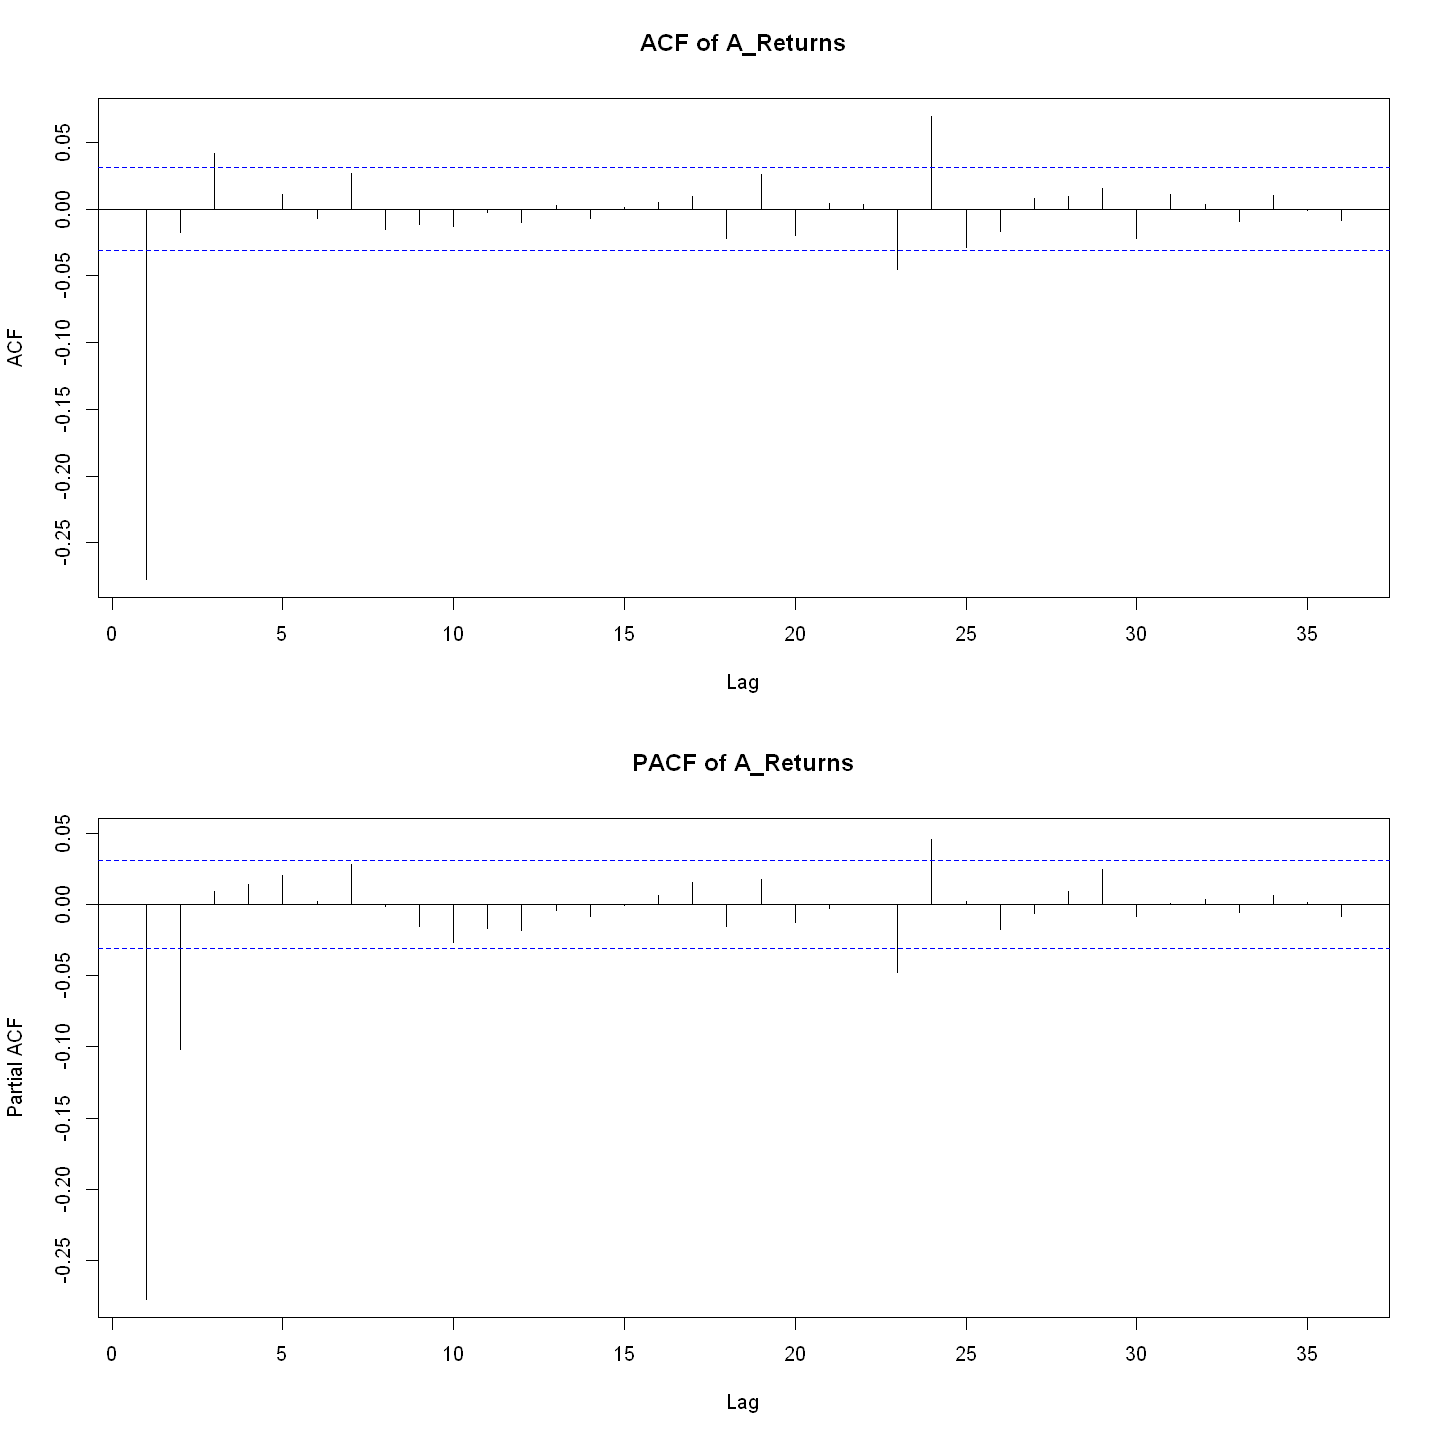

In [14]:
options(repr.plot.width = 12, repr.plot.height = 12)
par(mfrow = c(2, 1))
Acf(series_A$ret, main="ACF of A_Returns")
Pacf(series_A$ret, main="PACF of A_Returns")

**ACF** cuts off after first lag, with barely significant lag 3 and **PACF**  cuts off after significant 1st and 2nd lags. Since both ACF and PACF drop imidiately after the respective lags, we suspect either AR or MA process. We would expect MA(1), AR(2), to be most likely and further we estimate ARMA(1,1) for comparison. We do not include further lags to prevent overfitting, as in seminar the key takeaway was to keep these types of models simple.

In [30]:
A_ma1 <- Arima(series_A$ret, order = c(0, 0, 1))
summary(A_ma1)
A_ar2 <- Arima(series_A$ret, order = c(2, 0, 0))
summary(A_ar2)
A_arma11 <- Arima(series_A$ret, order = c(1, 0, 1))
summary(A_arma11)

Series: series_A$ret 
ARIMA(0,0,1) with non-zero mean 

Coefficients:
          ma1   mean
      -0.3012  1e-04
s.e.   0.0147  1e-04

sigma^2 = 0.0001008:  log likelihood = 12729.8
AIC=-25453.59   AICc=-25453.59   BIC=-25434.71

Training set error measures:
                        ME       RMSE        MAE      MPE     MAPE      MASE
Training set -4.622998e-08 0.01003778 0.00798011 106.2978 207.3473 0.5986774
                    ACF1
Training set -0.00296057

Series: series_A$ret 
ARIMA(2,0,0) with non-zero mean 

Coefficients:
          ar1      ar2   mean
      -0.3052  -0.1019  1e-04
s.e.   0.0157   0.0157  1e-04

sigma^2 = 0.0001006:  log likelihood = 12733.43
AIC=-25458.86   AICc=-25458.85   BIC=-25433.68

Training set error measures:
                        ME       RMSE         MAE      MPE     MAPE      MASE
Training set -4.791682e-07 0.01002866 0.007974574 103.2031 208.6005 0.5982621
                     ACF1
Training set 0.0008316948

Series: series_A$ret 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
          ar1      ma1   mean
      -0.0262  -0.2781  1e-04
s.e.   0.0459   0.0434  1e-04

sigma^2 = 0.0001008:  log likelihood = 12729.94
AIC=-25451.88   AICc=-25451.87   BIC=-25426.7

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 4.848184e-08 0.01003742 0.007981725 105.7151 208.6477 0.5987986
                      ACF1
Training set -0.0002441463

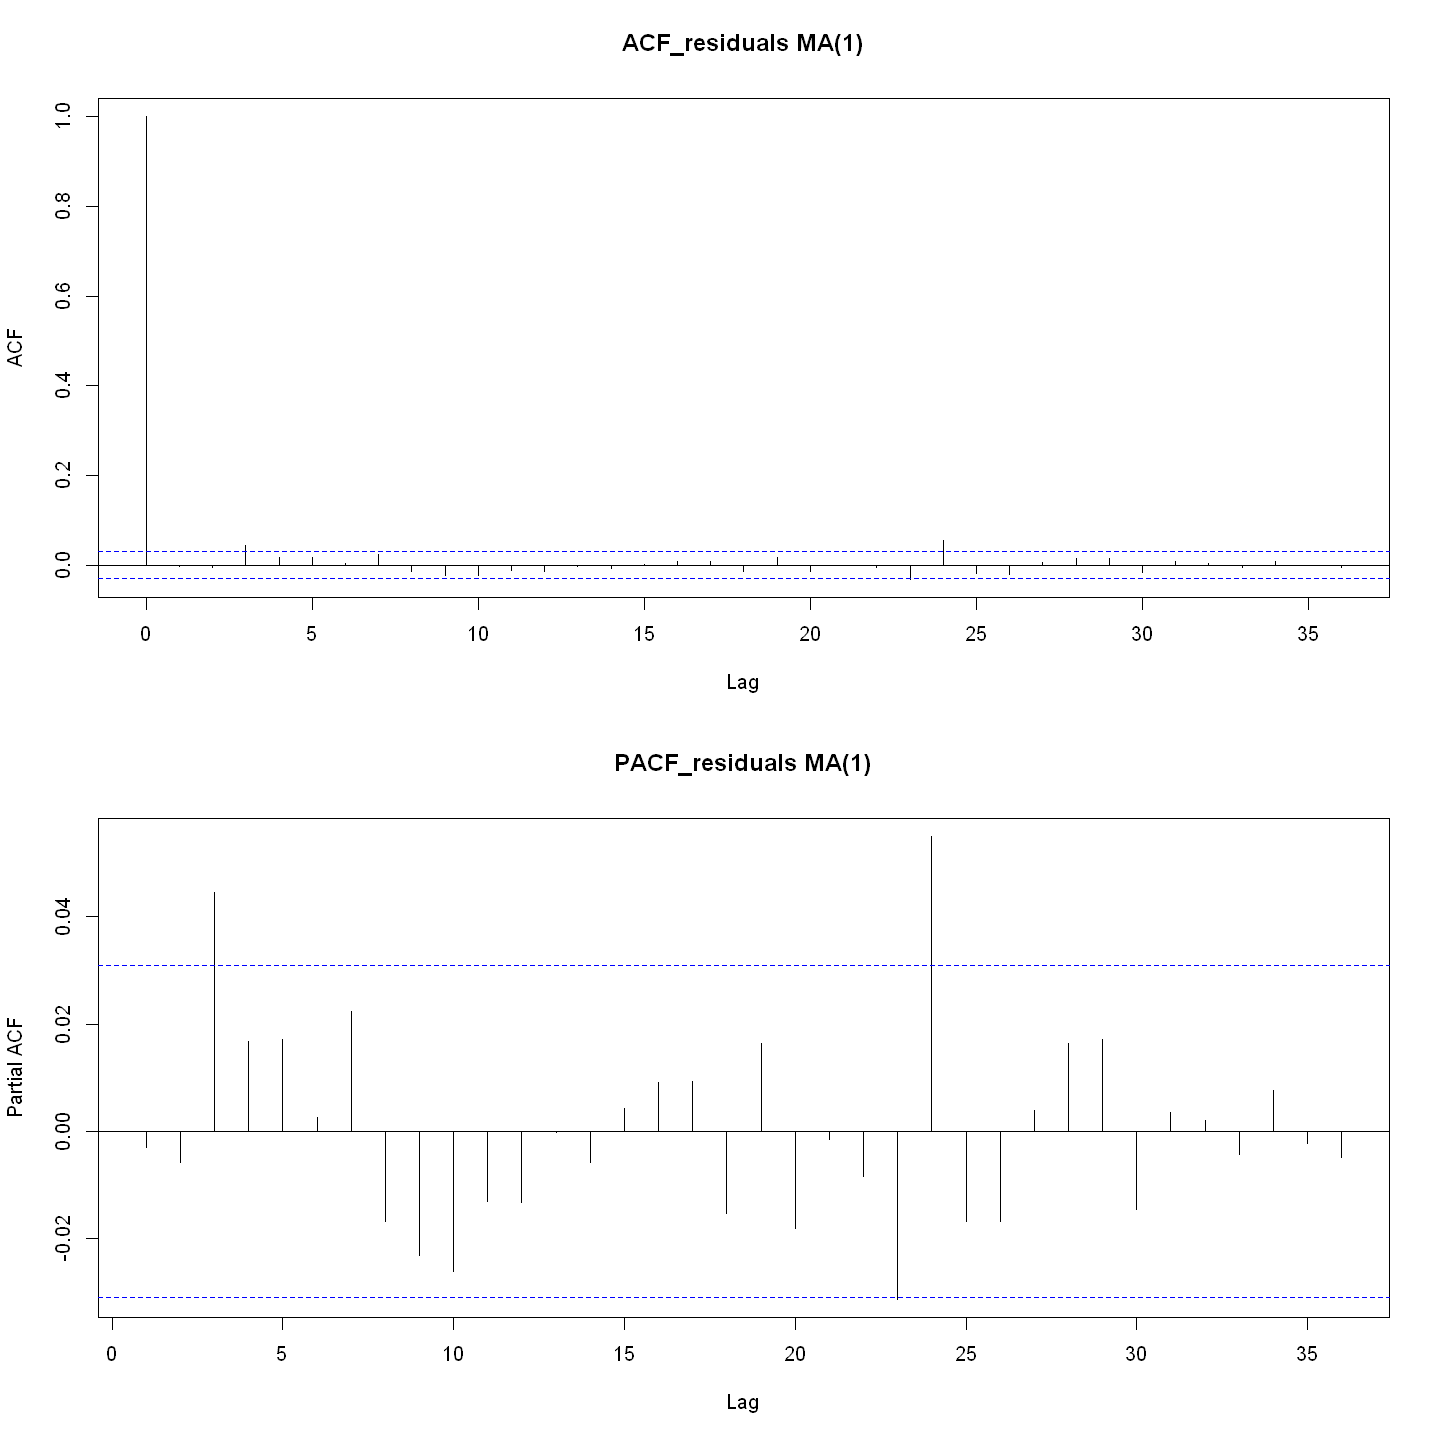

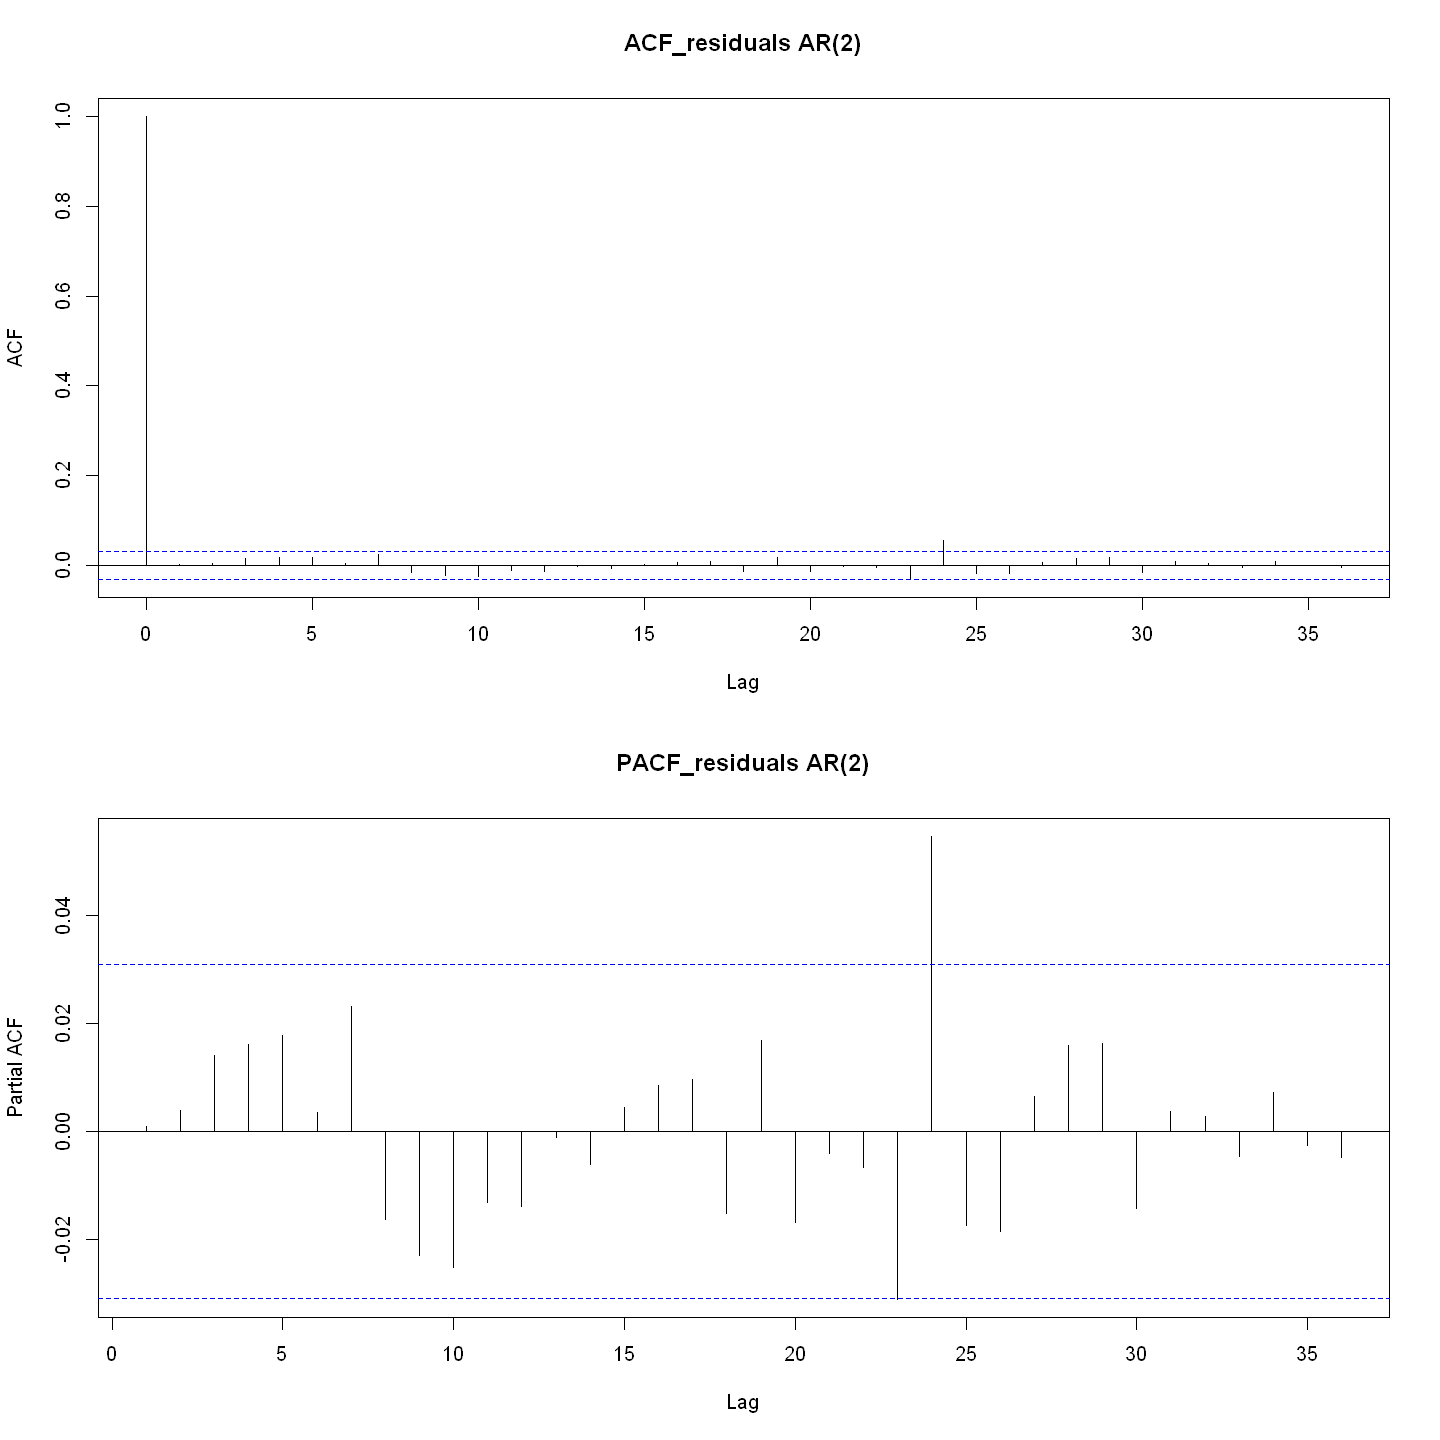

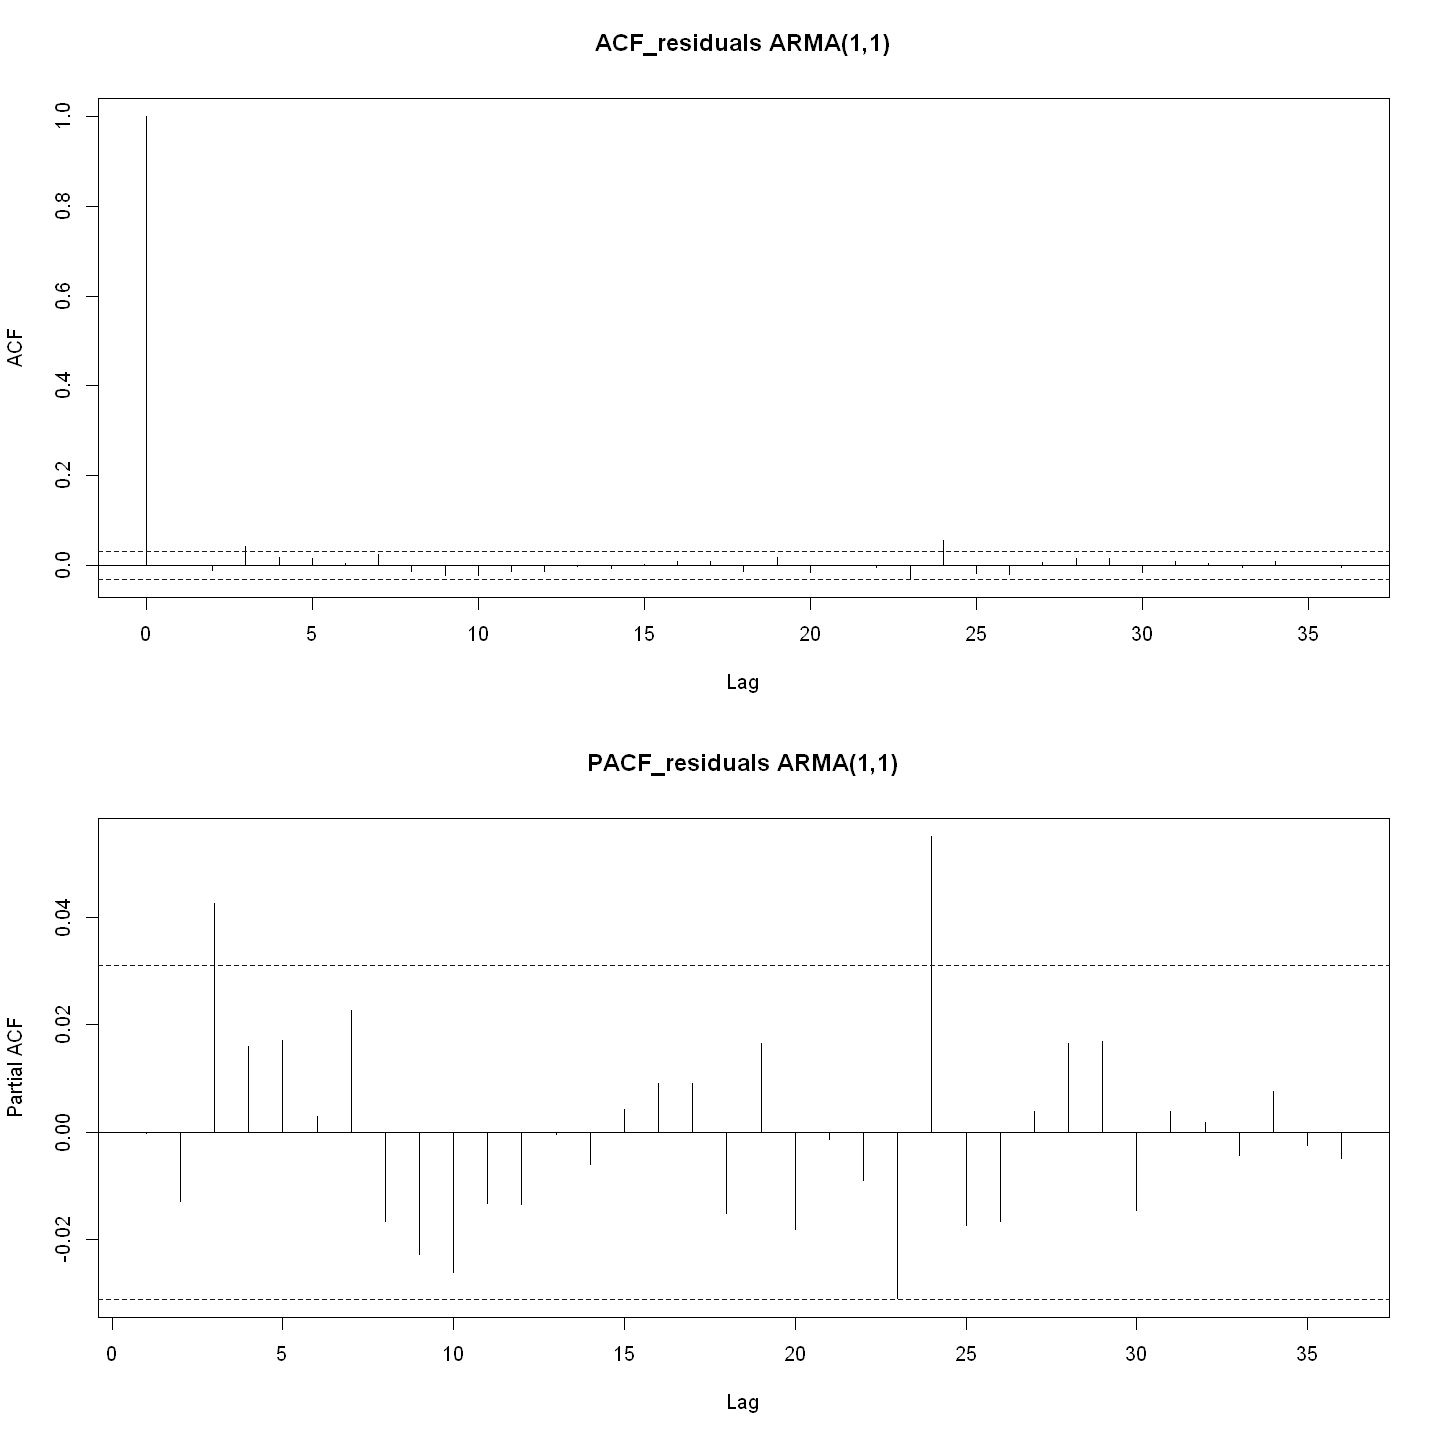

In [31]:
par(mfrow = c(2,1 ))
acf(A_ma1$residuals, main = "ACF_residuals MA(1)")
pacf(A_ma1$residuals, main = "PACF_residuals MA(1)")
acf(A_ar2$residuals, main = "ACF_residuals AR(2)")
pacf(A_ar2$residuals, main = "PACF_residuals AR(2)")
acf(A_arma11$residuals, main = "ACF_residuals ARMA(1,1)")
pacf(A_arma11$residuals, main = "PACF_residuals ARMA(1,1)")

In [32]:
Box.test(A_ma1$residuals, type = "Ljung-Box", lag = 4)
Box.test(A_ma1$residuals, type = "Ljung-Box", lag = 8)
Box.test(A_ma1$residuals, type = "Ljung-Box", lag = 12)
Box.test(A_ar2$residuals, type = "Ljung-Box", lag = 4)
Box.test(A_ar2$residuals, type = "Ljung-Box", lag = 8)
Box.test(A_ar2$residuals, type = "Ljung-Box", lag = 12)
Box.test(A_arma11$residuals, type = "Ljung-Box", lag = 4)
Box.test(A_arma11$residuals, type = "Ljung-Box", lag = 8)
Box.test(A_arma11$residuals, type = "Ljung-Box", lag = 12)


	Box-Ljung test

data:  A_ma1$residuals
X-squared = 9.2267, df = 4, p-value = 0.05568



	Box-Ljung test

data:  A_ma1$residuals
X-squared = 13.521, df = 8, p-value = 0.09514



	Box-Ljung test

data:  A_ma1$residuals
X-squared = 19.181, df = 12, p-value = 0.08424



	Box-Ljung test

data:  A_ar2$residuals
X-squared = 1.8972, df = 4, p-value = 0.7547



	Box-Ljung test

data:  A_ar2$residuals
X-squared = 6.448, df = 8, p-value = 0.5972



	Box-Ljung test

data:  A_ar2$residuals
X-squared = 12.226, df = 12, p-value = 0.4277



	Box-Ljung test

data:  A_arma11$residuals
X-squared = 8.9645, df = 4, p-value = 0.06199



	Box-Ljung test

data:  A_arma11$residuals
X-squared = 13.18, df = 8, p-value = 0.1058



	Box-Ljung test

data:  A_arma11$residuals
X-squared = 18.831, df = 12, p-value = 0.09269


In [33]:
models <- 3
criteria <- matrix(ncol = 2, nrow = models)
colnames(criteria) <- c('AIC', 'BIC')
rownames(criteria) <- c('MA(1)','AR(2)' ,'ARMA(1,1)')

criteria[1, 1] <- A_ma1$aic
criteria[1, 2] <- A_ma1$bic
criteria[2, 1] <- A_ar2$aic
criteria[2, 2] <- A_ar2$bic
criteria[3, 1] <- A_arma11$aic
criteria[3, 2] <- A_arma11$bic

criteria

,AIC,BIC
MA(1),-25453.59,-25434.71
AR(2),-25458.86,-25433.68
"ARMA(1,1)",-25451.88,-25426.70


BIC is compensating for the amount of parameter estimates, therefore it gets closer to zero in this case for models with more parameters

All three models perform very similarly . The MA(1) and ARMA(1,1) are basically identital in most measures also in the residual plots, to keep simplicity in the model we prefer the MA(1). And to choose between AR(2) and MA(1) we look mostly at the residual plots and information criteria since the original ACF and PACF do not clearly indicate one over another. Since the residual plot of AR(2) less significe at lag 3 and has lower information criteria we prefer **AR(2) for the series A**

#### Series B Box-Jenkins

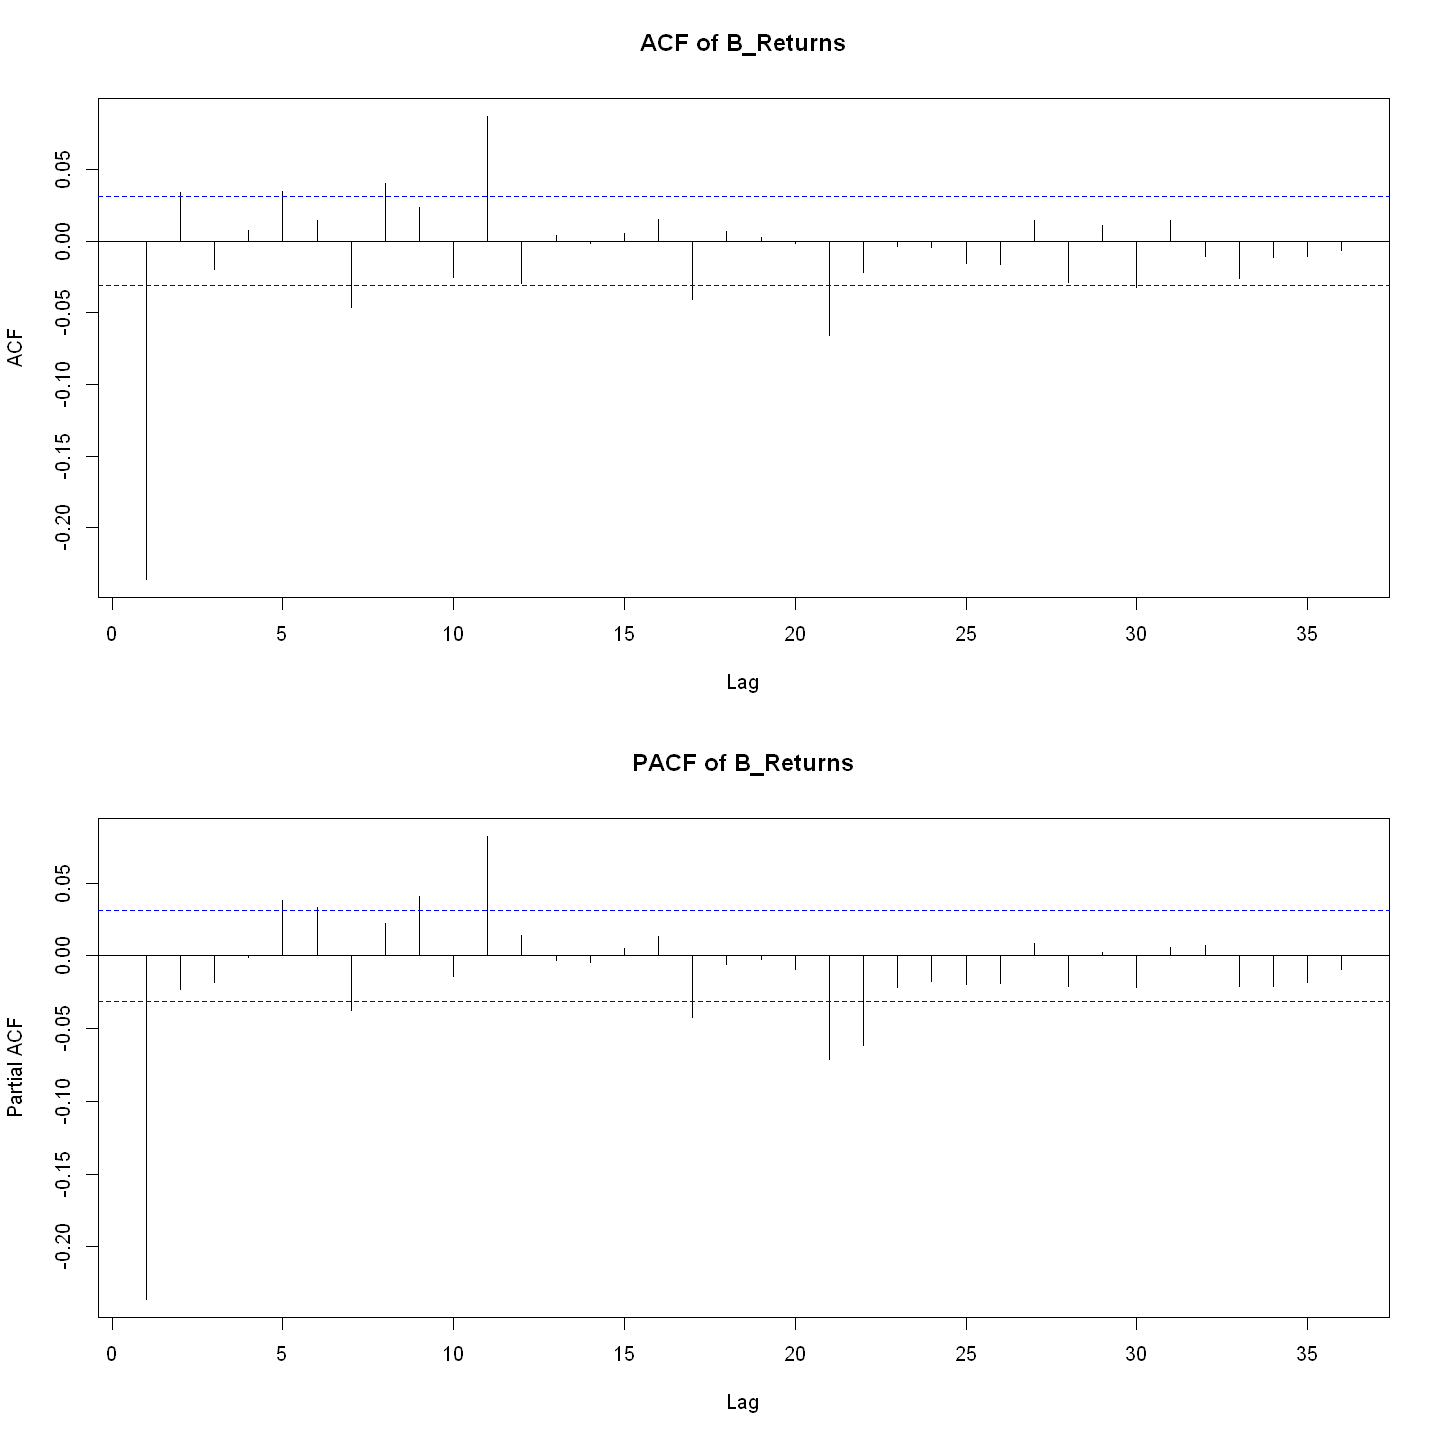

In [23]:
options(repr.plot.width = 12, repr.plot.height = 12)
par(mfrow = c(2, 1))
Acf(series_B$ret, main="ACF of B_Returns")
Pacf(series_B$ret, main="PACF of B_Returns")

The ACF and PACF  have similar patter as the series A. However here there is no significant further lag than one and the later lags such as the 11th we do not want to estimate to keep the simplicity in the model. In this series we expect the volatility modelling to be the better model as the volatility is clustered as shown in problem 1. Most plausible models to estimate are the MA(1), AR(1) and ARMA(1,1)

In [24]:
B_ma1 <- Arima(series_B$ret, order = c(0, 0, 1))
summary(B_ma1)
B_ar1 <- Arima(series_B$ret, order = c(1, 0, 0))
summary(B_ar1)
B_arma11 <- Arima(series_B$ret, order = c(1, 0, 1))
summary(B_arma11)

Series: series_B$ret 
ARIMA(0,0,1) with non-zero mean 

Coefficients:
          ma1   mean
      -0.2352  0e+00
s.e.   0.0149  4e-04

sigma^2 = 0.0008873:  log likelihood = 8379.91
AIC=-16753.83   AICc=-16753.82   BIC=-16734.94

Training set error measures:
                       ME       RMSE        MAE      MPE     MAPE      MASE
Training set 3.644207e-08 0.02977983 0.02070669 146.0402 256.0495 0.6235934
                     ACF1
Training set -0.006953821

Series: series_B$ret 
ARIMA(1,0,0) with non-zero mean 

Coefficients:
          ar1   mean
      -0.2358  0e+00
s.e.   0.0154  4e-04

sigma^2 = 0.000887:  log likelihood = 8380.48
AIC=-16754.96   AICc=-16754.95   BIC=-16736.08

Training set error measures:
                       ME       RMSE        MAE      MPE     MAPE      MASE
Training set 2.027819e-07 0.02977561 0.02070193 170.3504 275.6803 0.6234501
                     ACF1
Training set -0.005487077

Series: series_B$ret 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
          ar1      ma1   mean
      -0.1308  -0.1113  0e+00
s.e.   0.0690   0.0694  4e-04

sigma^2 = 0.0008867:  log likelihood = 8381.71
AIC=-16755.42   AICc=-16755.41   BIC=-16730.24

Training set error measures:
                        ME       RMSE        MAE      MPE     MAPE      MASE
Training set -1.748854e-09 0.02976646 0.02069379 160.8253 271.8842 0.6232048
                     ACF1
Training set 0.0003941563

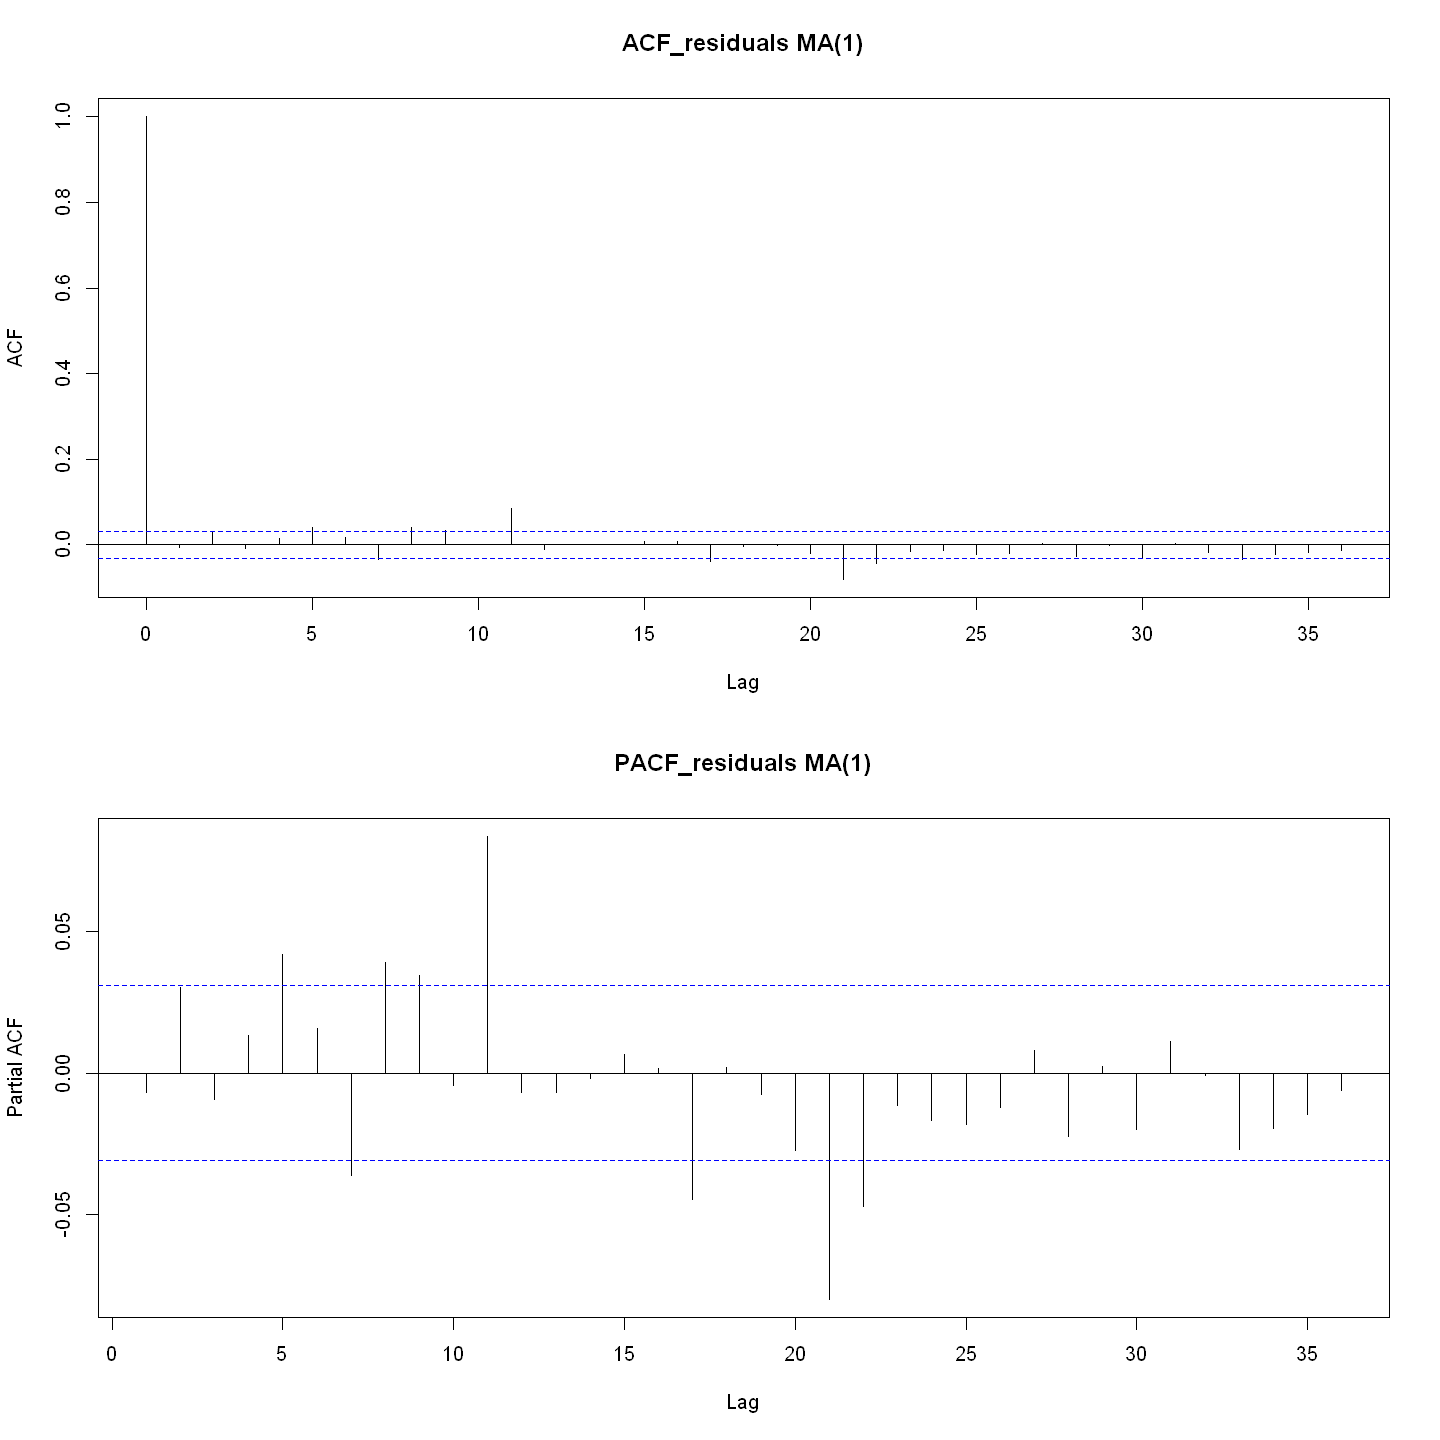

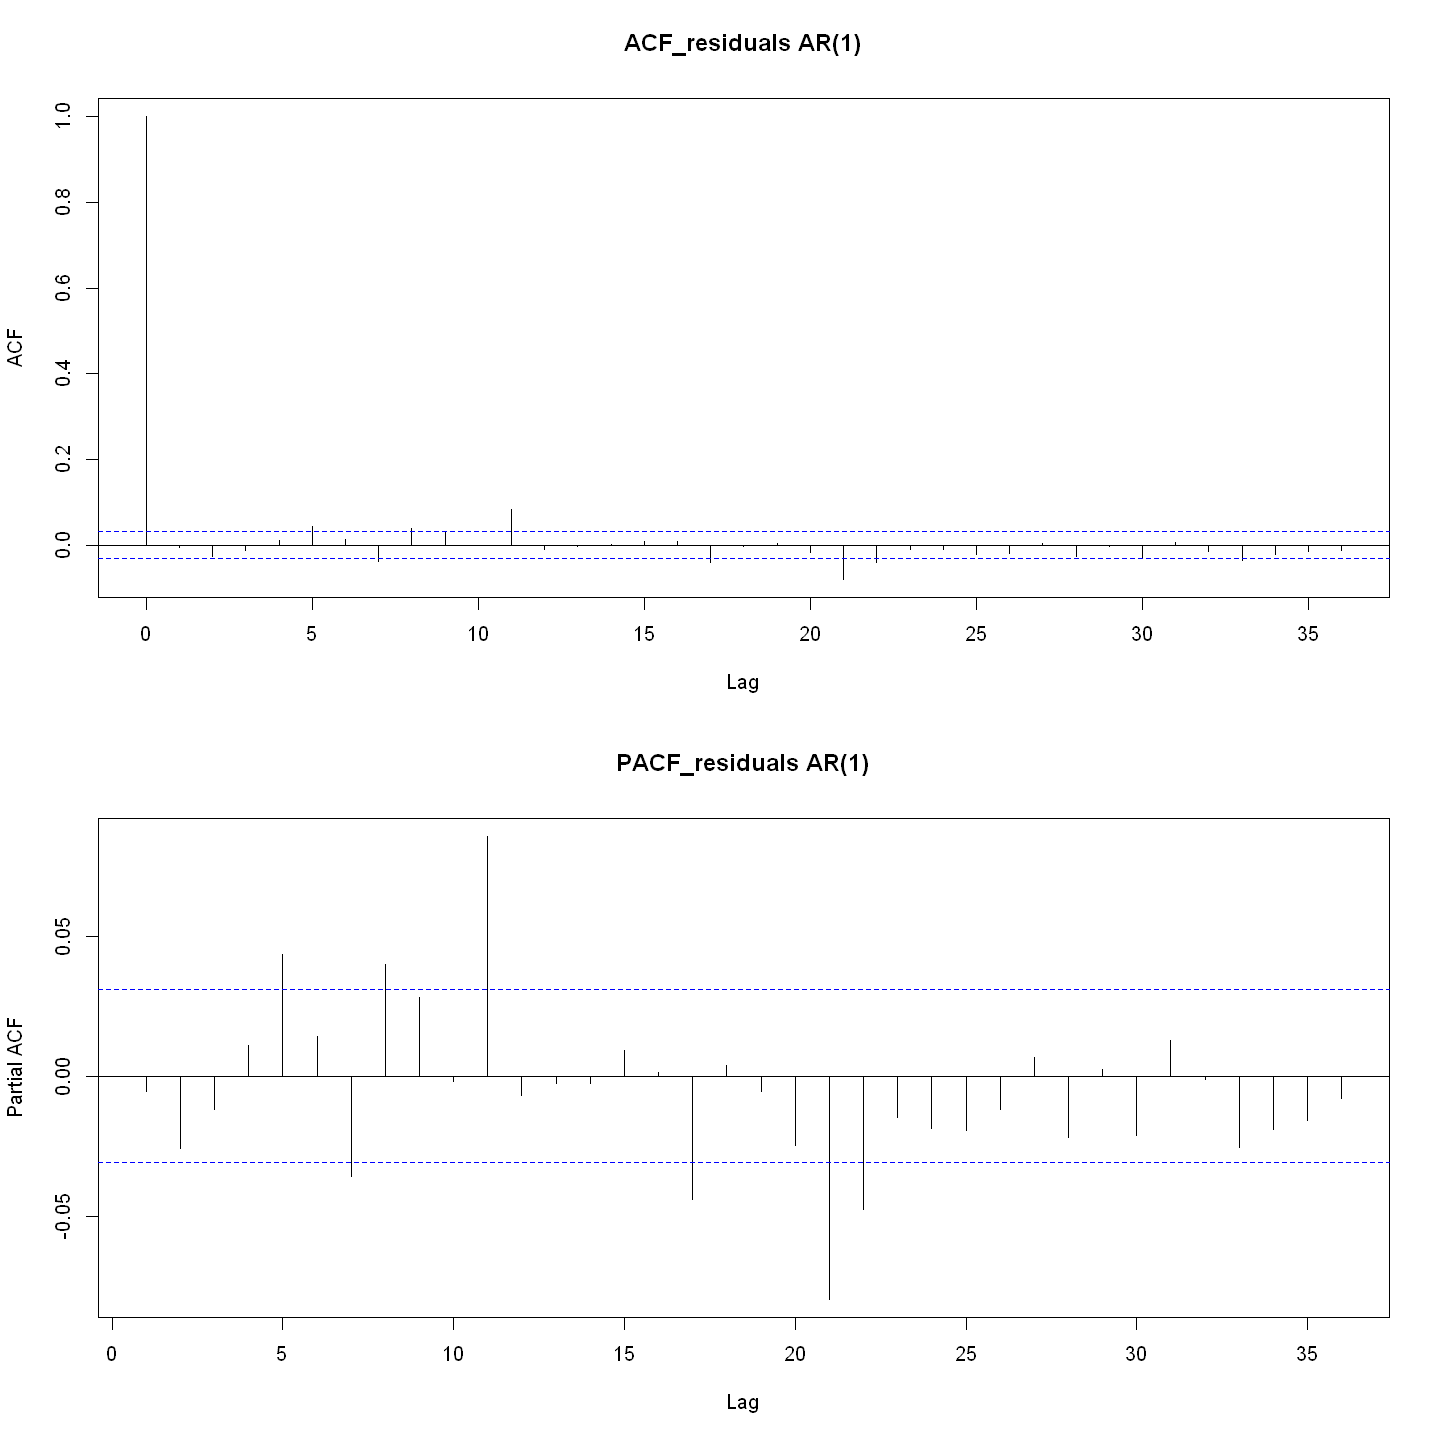

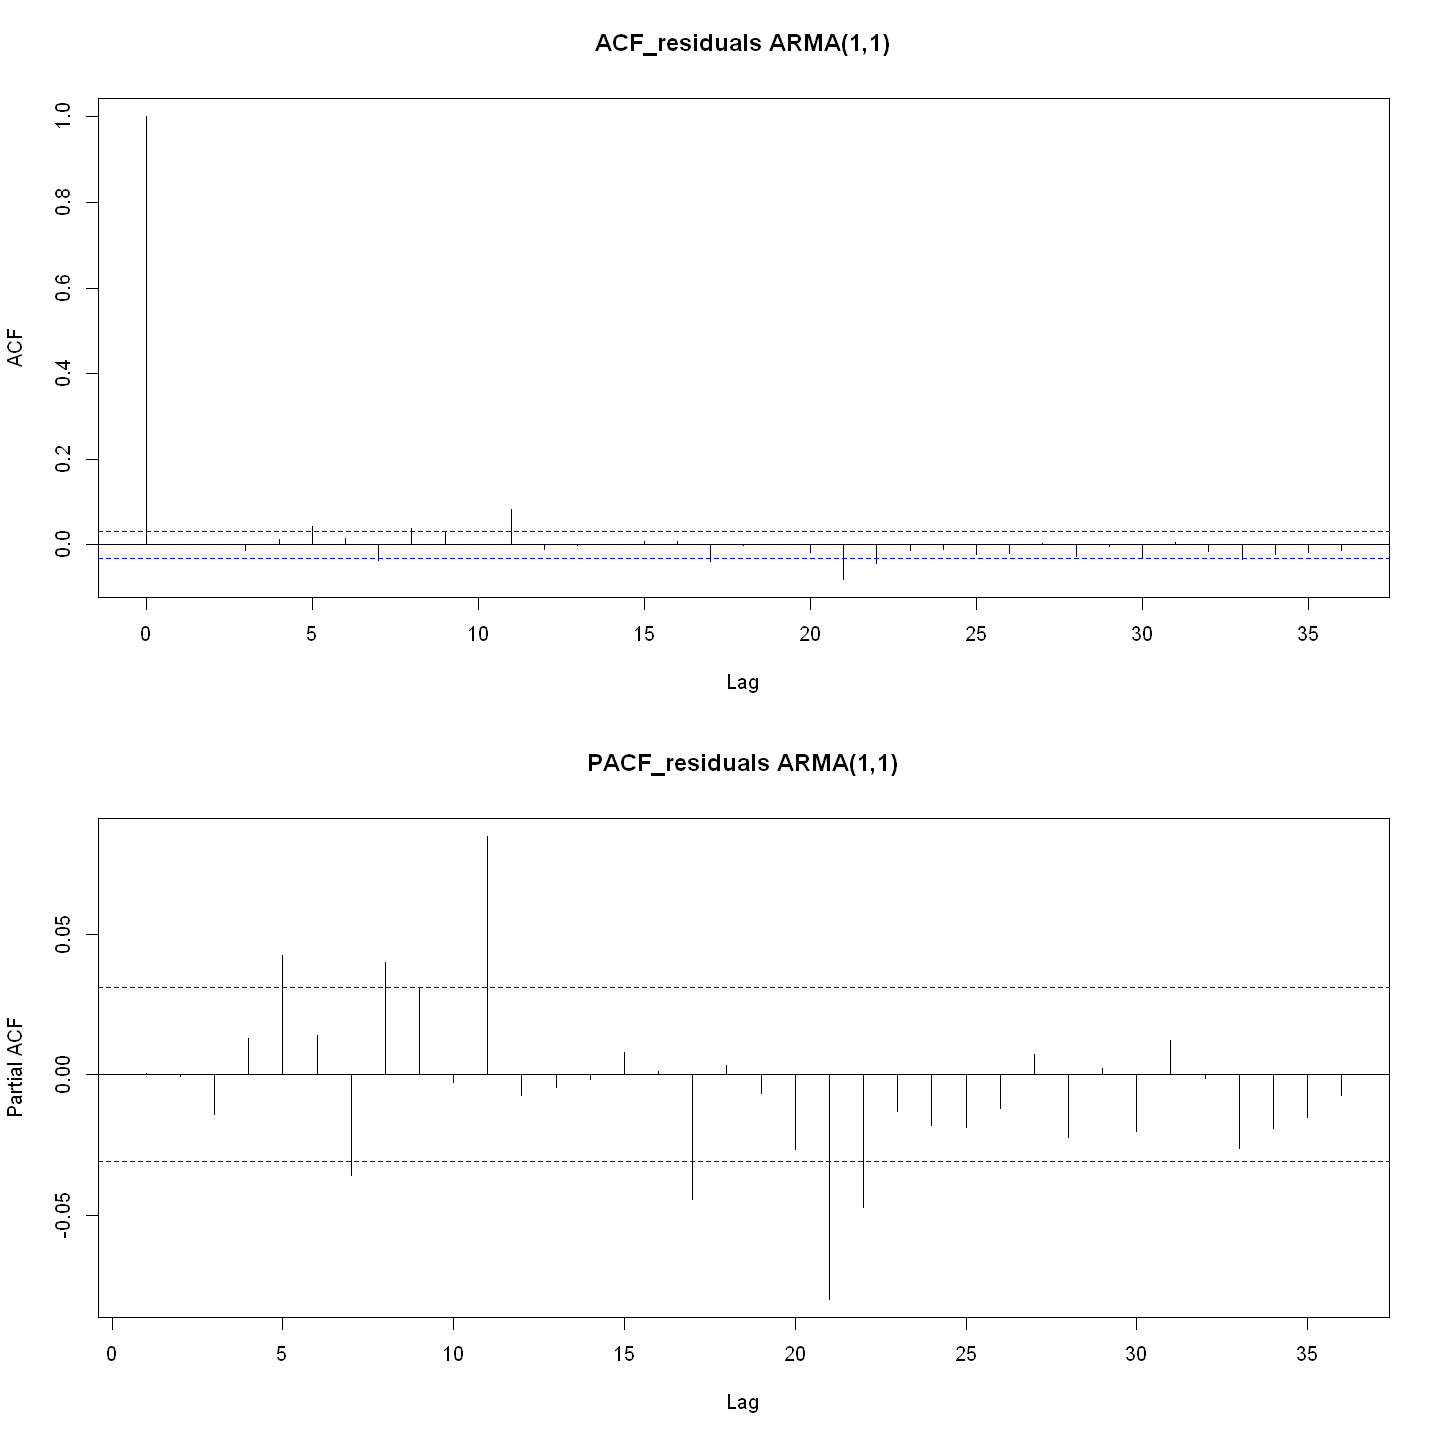

In [25]:
par(mfrow = c(2,1 ))
acf(B_ma1$residuals, main = "ACF_residuals MA(1)")
pacf(B_ma1$residuals, main = "PACF_residuals MA(1)")
acf(B_ar1$residuals, main = "ACF_residuals AR(1)")
pacf(B_ar1$residuals, main = "PACF_residuals AR(1)")
acf(B_arma11$residuals, main = "ACF_residuals ARMA(1,1)")
pacf(B_arma11$residuals, main = "PACF_residuals ARMA(1,1)")

In [54]:
Box.test(B_ma1$residuals, type = "Ljung-Box", lag = 4)
Box.test(B_ma1$residuals, type = "Ljung-Box", lag = 8)
Box.test(B_ma1$residuals, type = "Ljung-Box", lag = 12)
Box.test(B_ar1$residuals, type = "Ljung-Box", lag = 4)
Box.test(B_ar1$residuals, type = "Ljung-Box", lag = 8)
Box.test(B_ar1$residuals, type = "Ljung-Box", lag = 12)
Box.test(B_arma11$residuals, type = "Ljung-Box", lag = 4)
Box.test(B_arma11$residuals, type = "Ljung-Box", lag = 8)
Box.test(B_arma11$residuals, type = "Ljung-Box", lag = 12)


	Box-Ljung test

data:  B_ma1$residuals
X-squared = 5.0612, df = 4, p-value = 0.2811



	Box-Ljung test

data:  B_ma1$residuals
X-squared = 23.872, df = 8, p-value = 0.002408



	Box-Ljung test

data:  B_ma1$residuals
X-squared = 57.346, df = 12, p-value = 6.844e-08



	Box-Ljung test

data:  B_ar1$residuals
X-squared = 3.9309, df = 4, p-value = 0.4154



	Box-Ljung test

data:  B_ar1$residuals
X-squared = 24.252, df = 8, p-value = 0.002079



	Box-Ljung test

data:  B_ar1$residuals
X-squared = 55.97, df = 12, p-value = 1.212e-07



	Box-Ljung test

data:  B_arma11$residuals
X-squared = 1.4527, df = 4, p-value = 0.835



	Box-Ljung test

data:  B_arma11$residuals
X-squared = 20.796, df = 8, p-value = 0.00771



	Box-Ljung test

data:  B_arma11$residuals
X-squared = 53.207, df = 12, p-value = 3.785e-07


In [55]:
models <- 3
criteria <- matrix(ncol = 2, nrow = models)
colnames(criteria) <- c('AIC', 'BIC')
rownames(criteria) <- c('MA(1)','AR(1)' ,'ARMA(1,1)')

criteria[1, 1] <- B_ma1$aic
criteria[1, 2] <- B_ma1$bic
criteria[2, 1] <- B_ar1$aic
criteria[2, 2] <- B_ar1$bic
criteria[3, 1] <- B_arma11$aic
criteria[3, 2] <- B_arma11$bic

criteria

,AIC,BIC
MA(1),-16753.83,-16734.94
AR(1),-16754.96,-16736.08
"ARMA(1,1)",-16755.42,-16730.24


BIC is compensating for the amount of parameter estimates, therefore it gets closer to zero in this case for models with more parameters

Since there is virtually no evidence supporting AR(1) over MA(1) and vice versa we make the decision through information criteia. These favor the **AR(1)** as the most plausible mean model for the **series B**

#### Series C Box-Jenkins

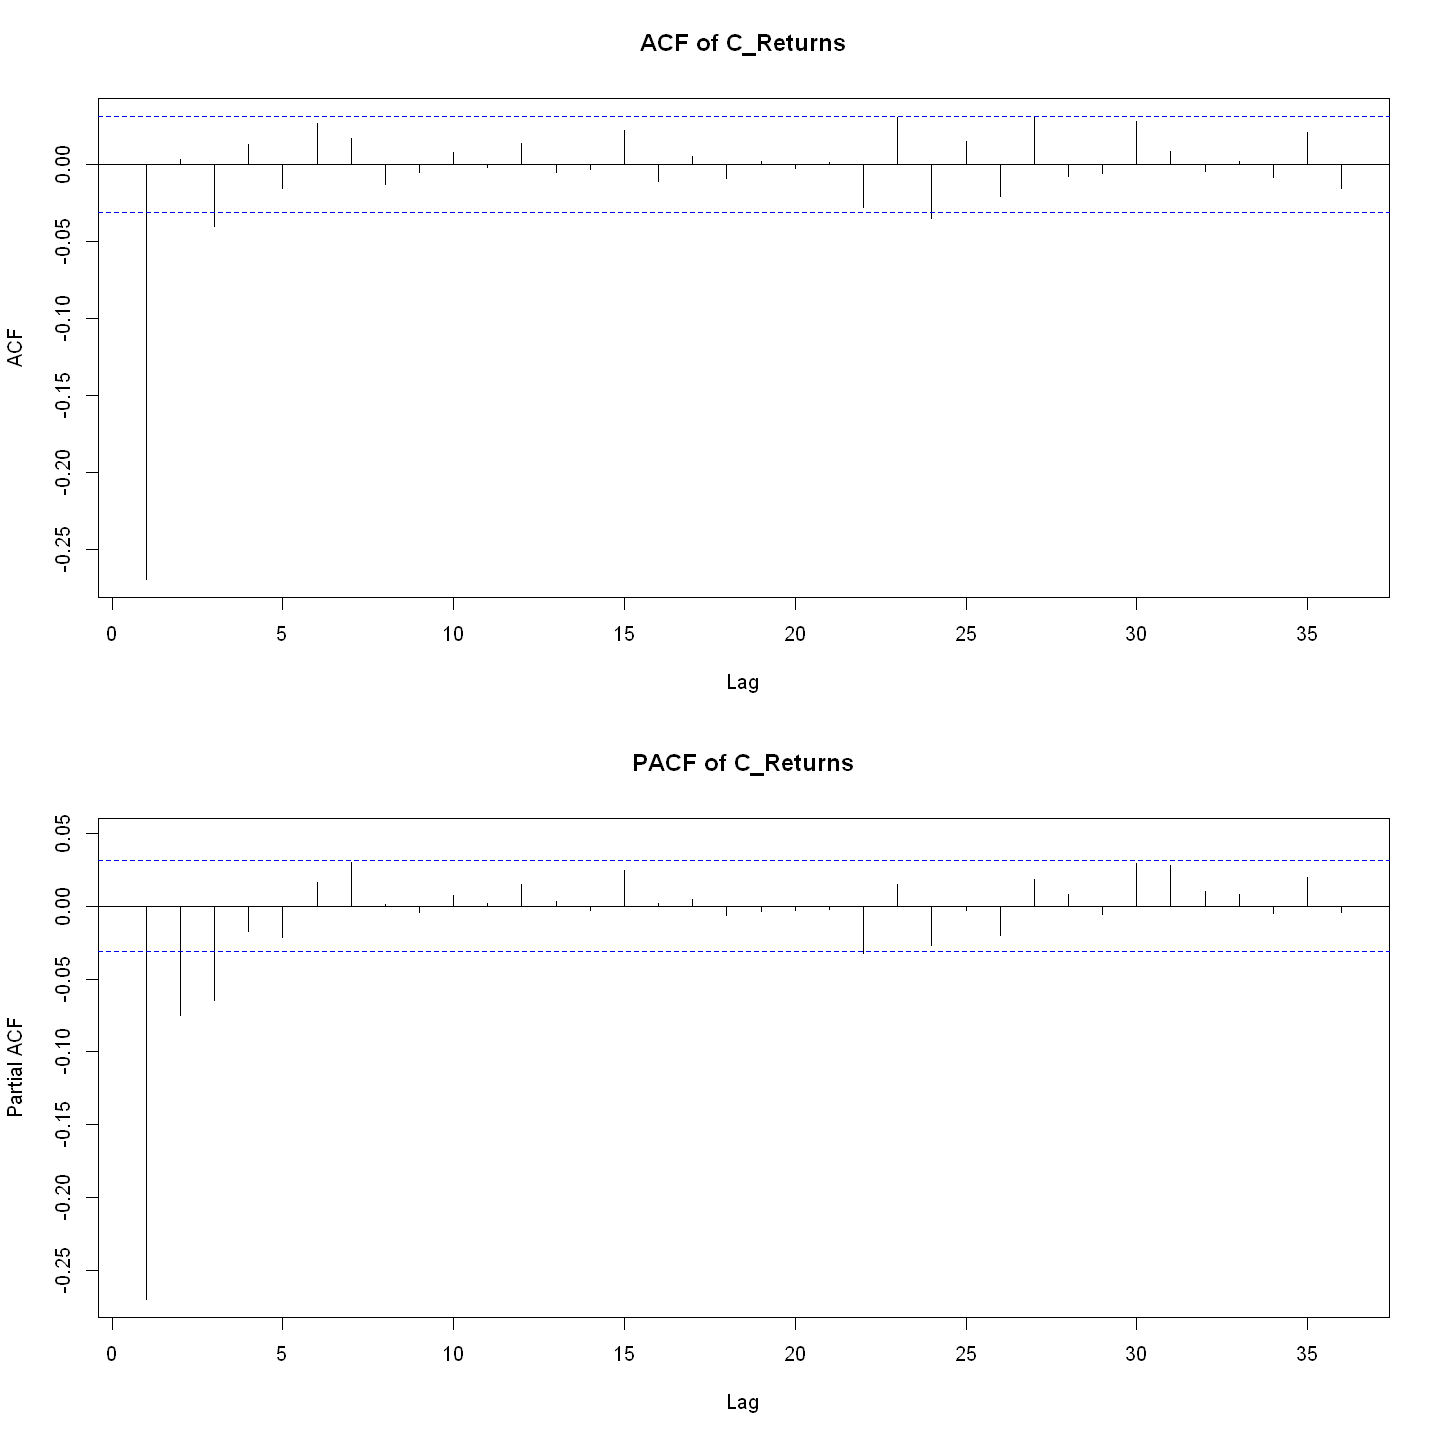

In [34]:
options(repr.plot.width = 12, repr.plot.height = 12)
par(mfrow = c(2, 1))
Acf(series_C$ret, main="ACF of C_Returns")
Pacf(series_C$ret, main="PACF of C_Returns")

Since the **PACF** decays slowly and the **ACF** dropps after the first lag we are highly expecting this process to be MA(1) and we add also MA(3) since the third lag in ACF is slightly significant. Lastly we will also estimate arma(1,1) as a comparison and check for ARMA specification.

In [40]:
C_ma3 <- Arima(series_C$ret, order = c(0, 0, 3))
summary(C_ma3)
C_ma1 <- Arima(series_C$ret, order = c(0, 0, 1))
summary(C_ma1)
C_arma11 <- Arima(series_C$ret, order = c(1, 0, 1))
summary(C_arma11)

Series: series_C$ret 
ARIMA(0,0,3) with non-zero mean 

Coefficients:
          ma1      ma2      ma3   mean
      -0.2953  -0.0082  -0.0338  0e+00
s.e.   0.0158   0.0163   0.0153  1e-04

sigma^2 = 0.0001058:  log likelihood = 12634.95
AIC=-25259.9   AICc=-25259.89   BIC=-25228.43

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 2.160327e-07 0.01027863 0.008110659 109.9061 195.9455 0.6054188
                      ACF1
Training set -0.0005747847

Series: series_C$ret 
ARIMA(0,0,1) with non-zero mean 

Coefficients:
          ma1   mean
      -0.3016  0e+00
s.e.   0.0155  1e-04

sigma^2 = 0.0001059:  log likelihood = 12631.76
AIC=-25257.53   AICc=-25257.52   BIC=-25238.65

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 2.734403e-07 0.01028682 0.008111785 106.8524 193.9495 0.6055029
                    ACF1
Training set 0.005926602

Series: series_C$ret 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
         ar1      ma1   mean
      0.0754  -0.3713  0e+00
s.e.  0.0554   0.0520  1e-04

sigma^2 = 0.0001058:  log likelihood = 12632.72
AIC=-25257.43   AICc=-25257.42   BIC=-25232.25

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 1.741883e-06 0.01028437 0.008114591 105.4373 192.3632 0.6057123
                     ACF1
Training set -0.000659122

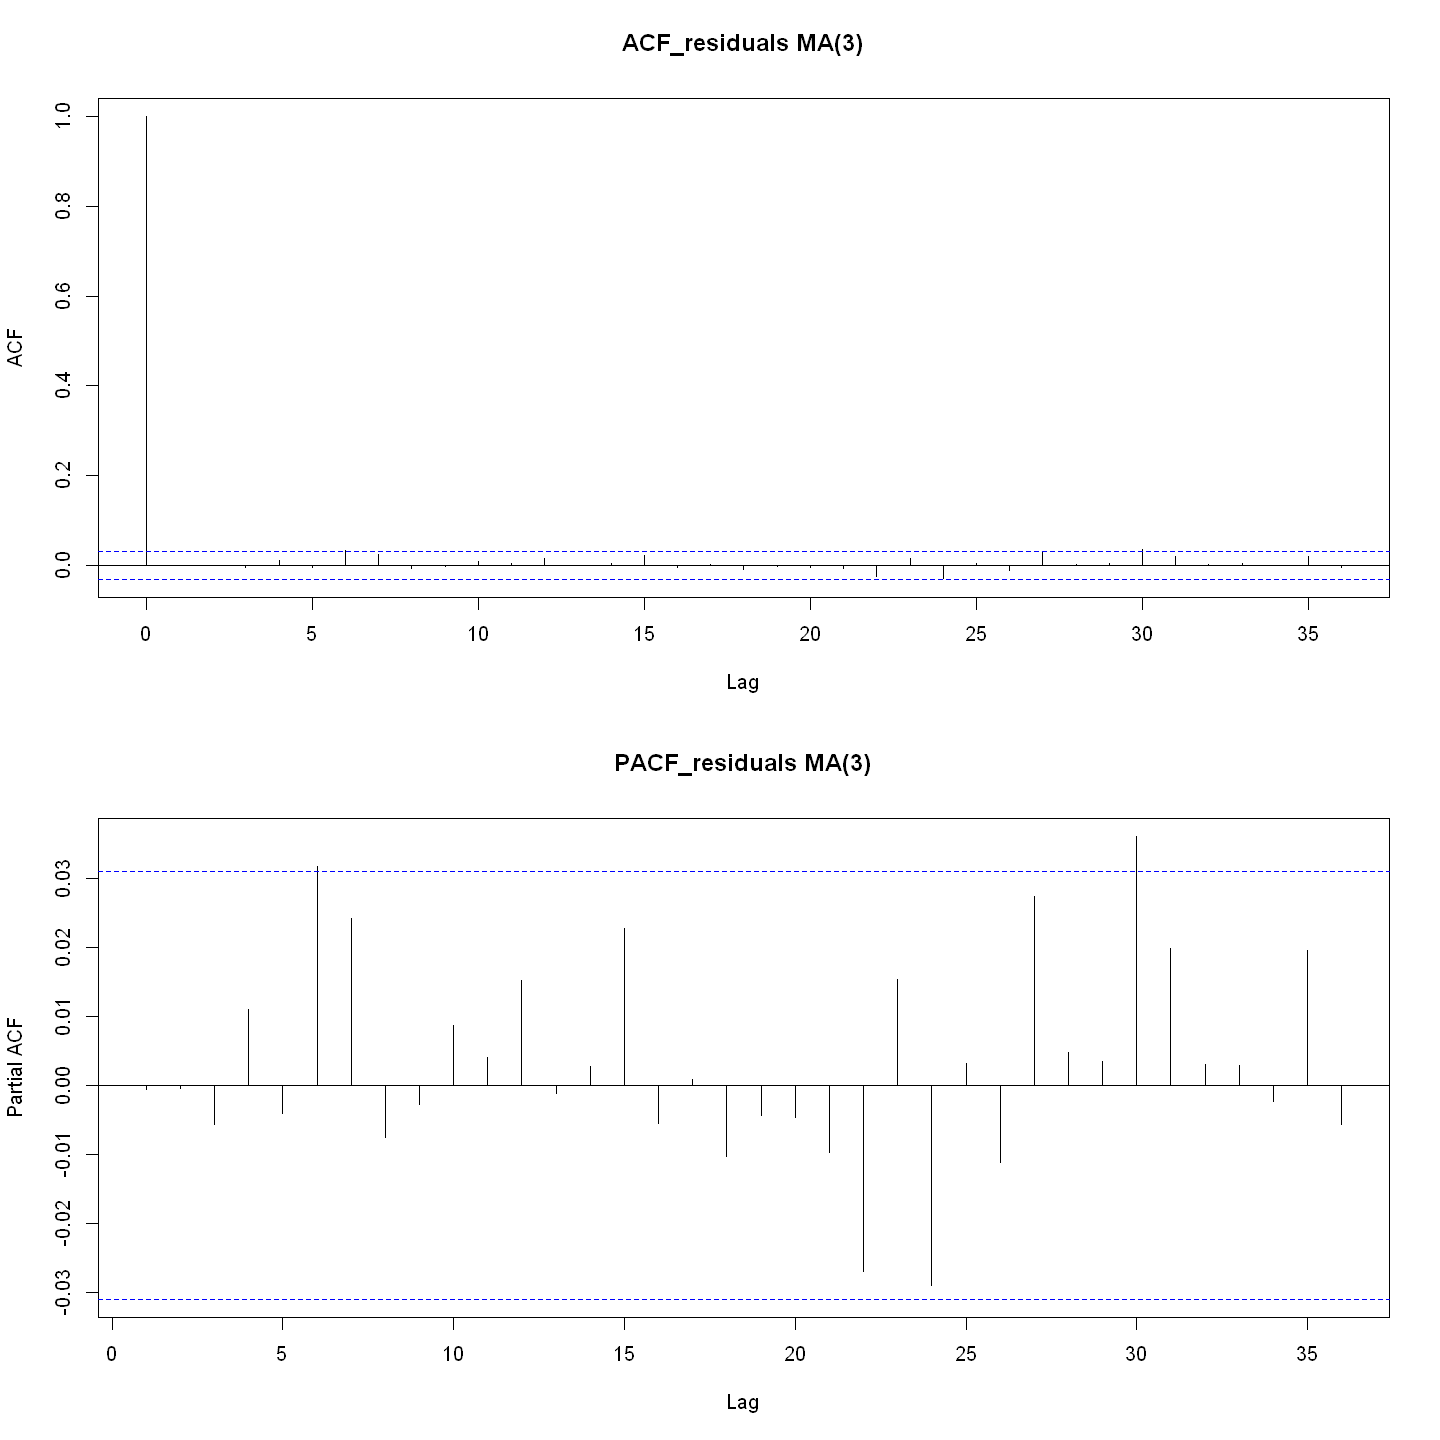

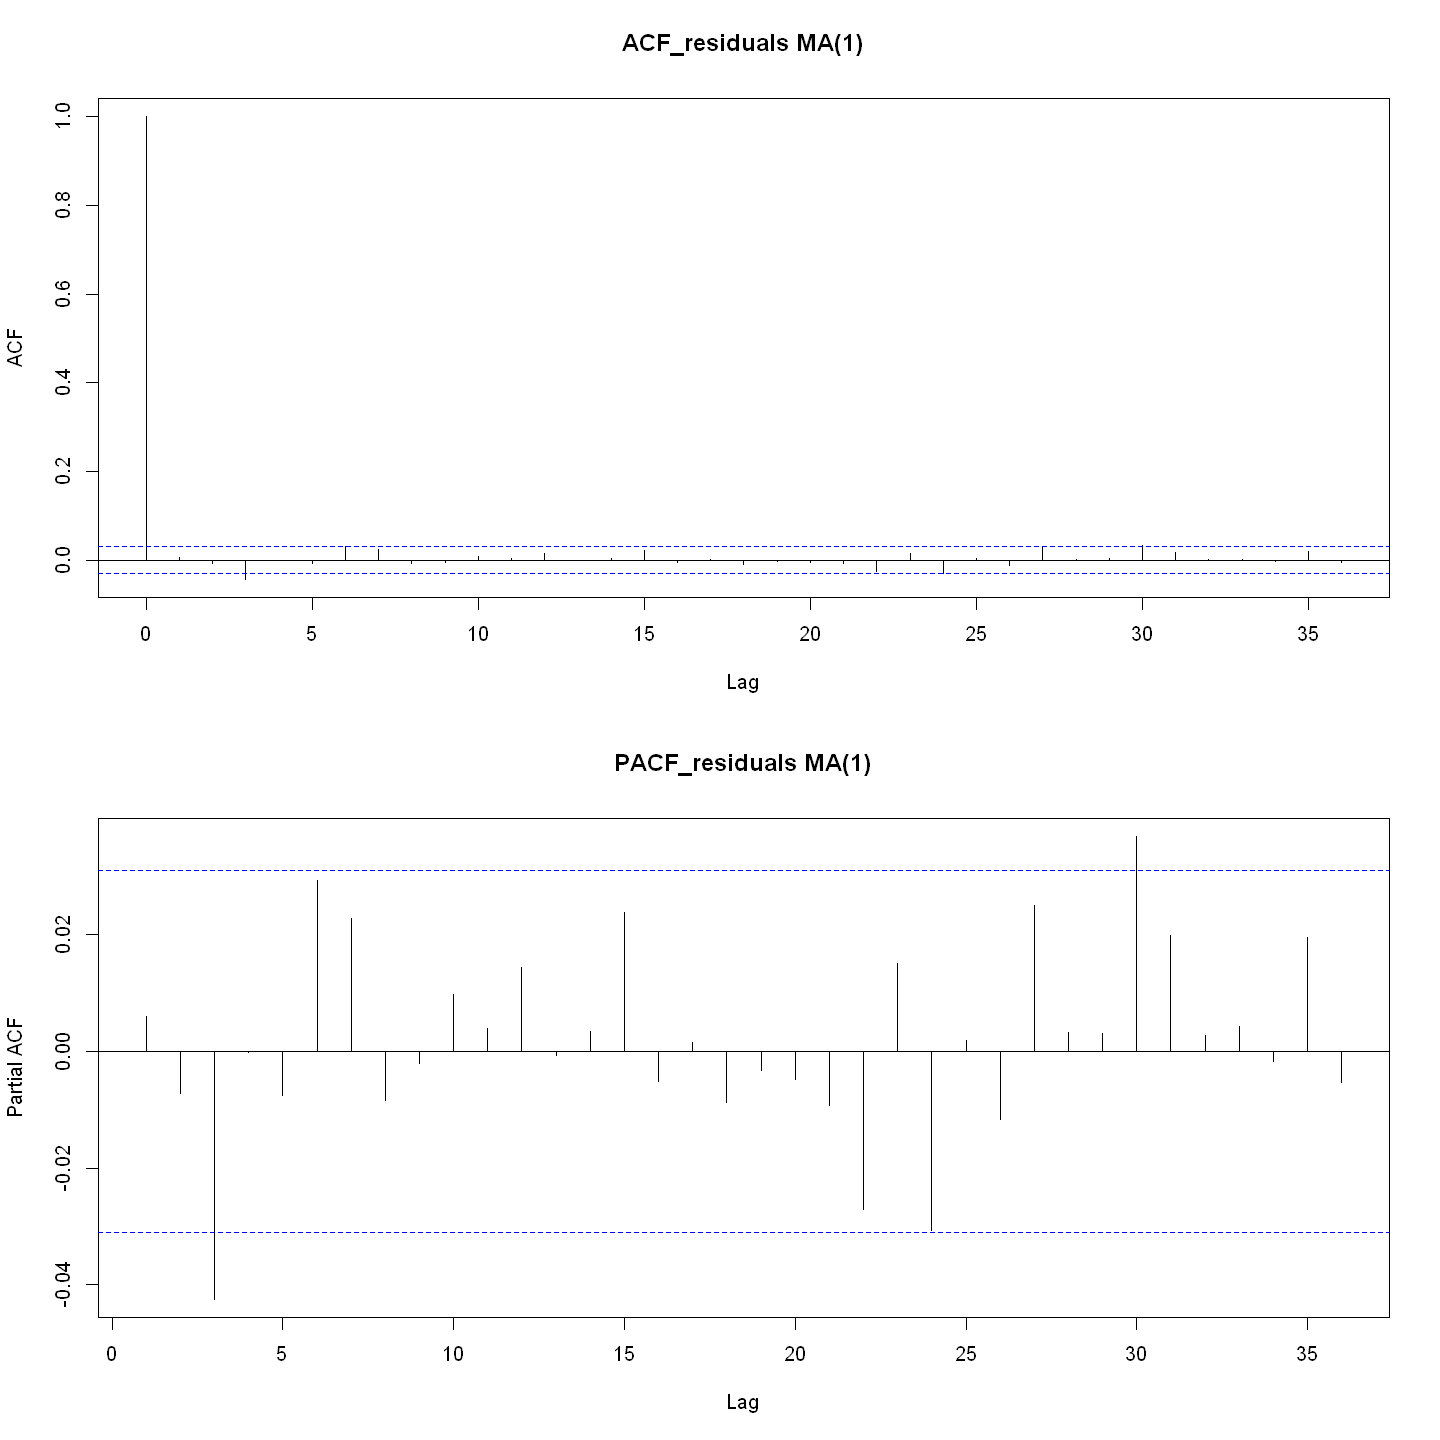

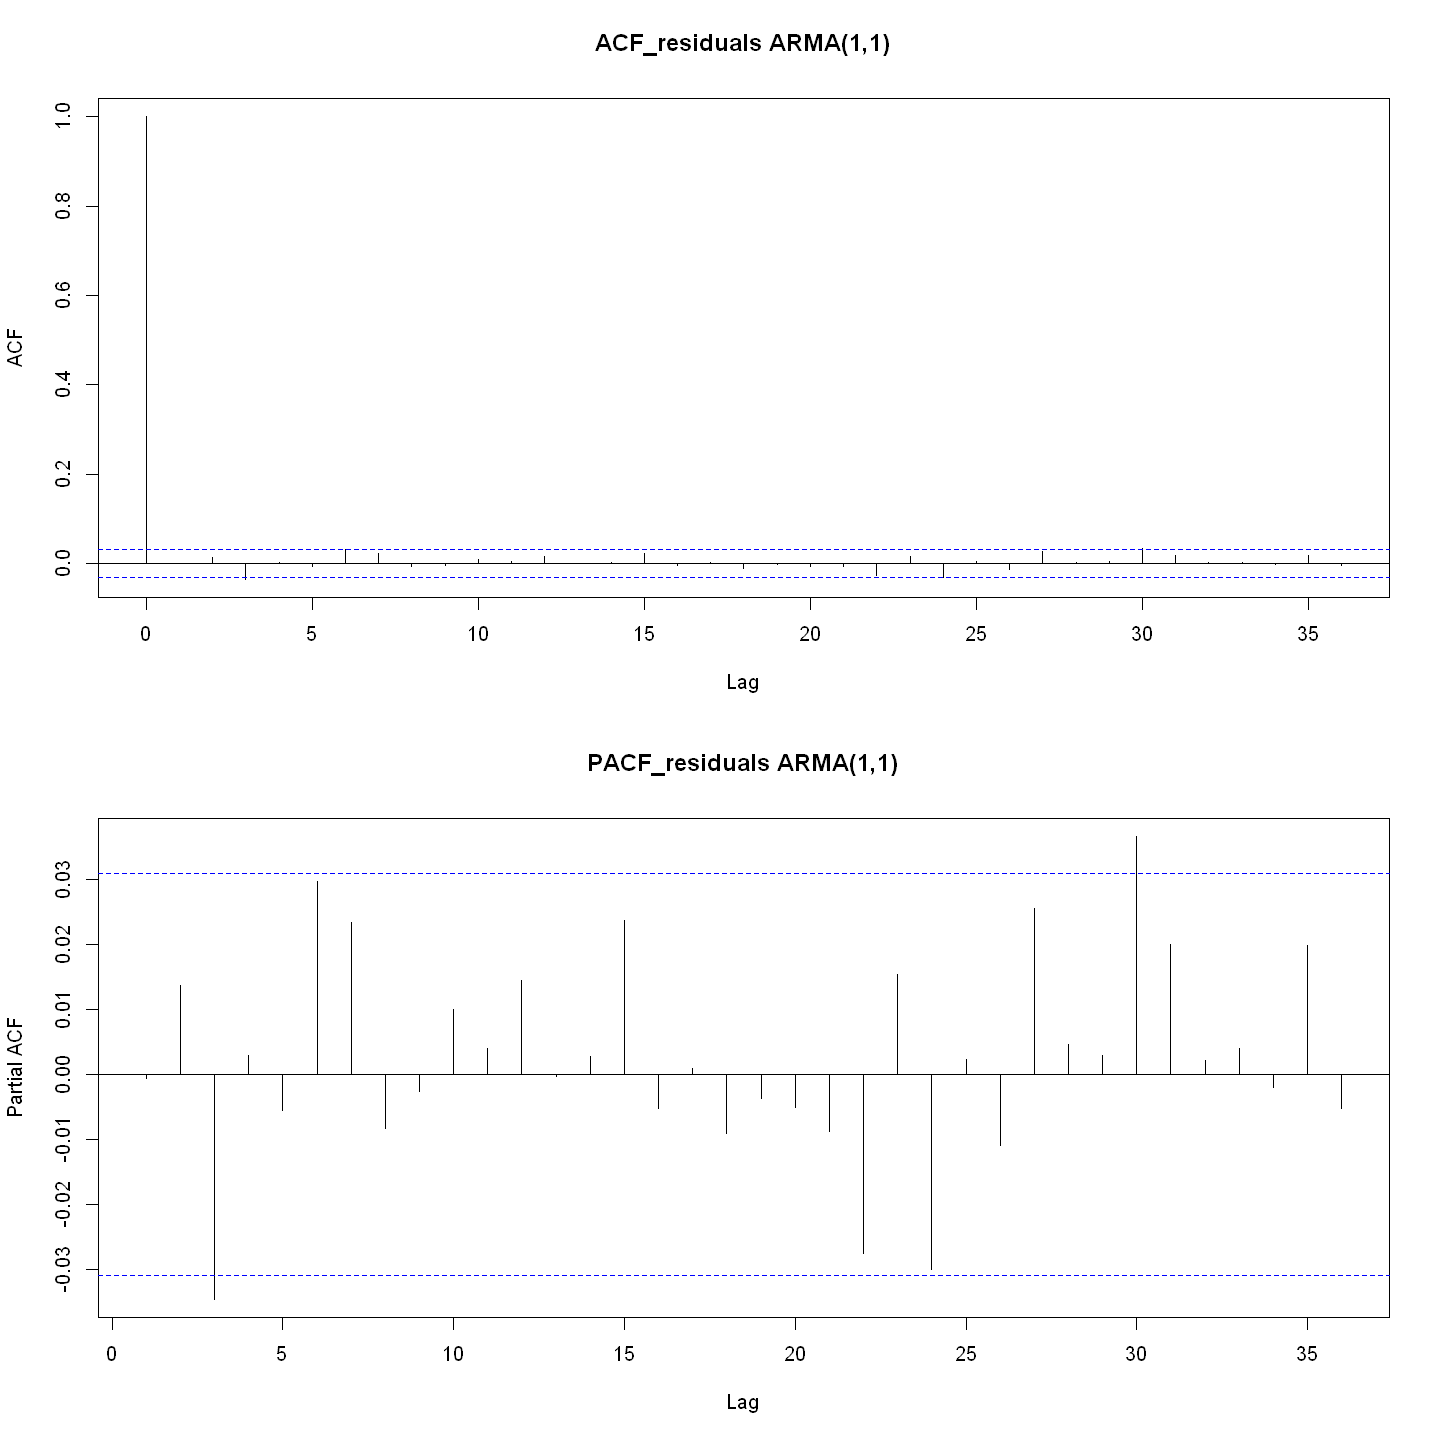

In [41]:
par(mfrow = c(2,1 ))
acf(C_ma3$residuals, main = "ACF_residuals MA(3)")
pacf(C_ma3$residuals, main = "PACF_residuals MA(3)")
acf(C_ma1$residuals, main = "ACF_residuals MA(1)")
pacf(C_ma1$residuals, main = "PACF_residuals MA(1)")
acf(C_arma11$residuals, main = "ACF_residuals ARMA(1,1)")
pacf(C_arma11$residuals, main = "PACF_residuals ARMA(1,1)")

In [42]:
Box.test(C_ma3$residuals, type = "Ljung-Box", lag = 4)
Box.test(C_ma3$residuals, type = "Ljung-Box", lag = 8)
Box.test(C_ma3$residuals, type = "Ljung-Box", lag = 12)
Box.test(C_ma1$residuals, type = "Ljung-Box", lag = 4)
Box.test(C_ma1$residuals, type = "Ljung-Box", lag = 8)
Box.test(C_ma1$residuals, type = "Ljung-Box", lag = 12)
Box.test(C_arma11$residuals, type = "Ljung-Box", lag = 4)
Box.test(C_arma11$residuals, type = "Ljung-Box", lag = 8)
Box.test(C_arma11$residuals, type = "Ljung-Box", lag = 12)


	Box-Ljung test

data:  C_ma3$residuals
X-squared = 0.62123, df = 4, p-value = 0.9607



	Box-Ljung test

data:  C_ma3$residuals
X-squared = 7.2787, df = 8, p-value = 0.5069



	Box-Ljung test

data:  C_ma3$residuals
X-squared = 8.7465, df = 12, p-value = 0.7244



	Box-Ljung test

data:  C_ma1$residuals
X-squared = 7.5989, df = 4, p-value = 0.1074



	Box-Ljung test

data:  C_ma1$residuals
X-squared = 14.077, df = 8, p-value = 0.07978



	Box-Ljung test

data:  C_ma1$residuals
X-squared = 15.421, df = 12, p-value = 0.2192



	Box-Ljung test

data:  C_arma11$residuals
X-squared = 5.5955, df = 4, p-value = 0.2315



	Box-Ljung test

data:  C_arma11$residuals
X-squared = 11.915, df = 8, p-value = 0.155



	Box-Ljung test

data:  C_arma11$residuals
X-squared = 13.292, df = 12, p-value = 0.3482


In [43]:
models <- 3
criteria <- matrix(ncol = 2, nrow = models)
colnames(criteria) <- c('AIC', 'BIC')
rownames(criteria) <- c('MA(3)','MA(1)' ,'ARMA(1,1)')

criteria[1, 1] <- C_ma3$aic
criteria[1, 2] <- C_ma3$bic
criteria[2, 1] <- C_ma1$aic
criteria[2, 2] <- C_ma1$bic
criteria[3, 1] <- C_arma11$aic
criteria[3, 2] <- C_arma11$bic

criteria

,AIC,BIC
MA(3),-25259.90,-25228.43
MA(1),-25257.53,-25238.65
"ARMA(1,1)",-25257.43,-25232.25


BIC is compensating for the amount of parameter estimates, therefore it gets closer to zero in this case for models with more parameters

All three models perform very similarly and therefore we prefer the most simple one, the **MA(1) for series C**